In [1]:
import pandas as pd
import os

files = {
    "original":  "../data/raw/crop_data.csv",
    "v2":        "../data/raw/crop_data_v2.csv",
    "v3":        "../data/raw/crop_data_v3.csv",
    "v4":        "../data/raw/crop_data_v4.csv",
    "v5":        "../data/raw/crop_data_v5.csv",
}

for name, path in files.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✓ {name}: {df.shape[0]} rows | columns: {list(df.columns)}")
    else:
        print(f"✗ {name}: FILE NOT FOUND at {path}")

✓ original: 2200 rows | columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
✓ v2: 2200 rows | columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
✓ v3: 2200 rows | columns: ['Nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'Unnamed: 8', 'Unnamed: 9']
✓ v4: 1000 rows | columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop']
✓ v5: 620 rows | columns: ['N', 'P', 'K', 'ph', 'EC', 'S', 'Cu', 'Fe', 'Mn', 'Zn', 'B', 'label']


In [2]:
# ============================================================
# DATASET EXPANSION V3 — Tuned to exact column names confirmed
# Works with: original, v2, v3, v4
# v5 is excluded (missing temperature, humidity, rainfall)
# ============================================================

import pandas as pd
import numpy as np
import os

os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../results/tables", exist_ok=True)

REQUIRED_COLS = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall", "label"]

# ============================================================
# PART 1: LOAD AND NORMALISE EACH DATASET INDIVIDUALLY
# ============================================================

frames = []

# --- Dataset 1: original (already correct columns) ---
d1 = pd.read_csv("../data/raw/crop_data.csv")
d1["source"] = "original"
frames.append(d1)
print(f"✓ original: {len(d1)} rows")

# --- Dataset 2: v2 (identical structure to original) ---
d2 = pd.read_csv("../data/raw/crop_data_v2.csv")
d2["source"] = "v2"
frames.append(d2)
print(f"✓ v2: {len(d2)} rows")

# --- Dataset 3: v3 (different column names + junk columns) ---
d3 = pd.read_csv("../data/raw/crop_data_v3.csv")
d3 = d3.rename(columns={
    "Nitrogen":   "N",
    "phosphorus": "P",
    "potassium":  "K",
})
# Drop the two unnamed junk columns
d3 = d3.drop(columns=[c for c in d3.columns if "Unnamed" in c], errors="ignore")
d3["source"] = "v3"
frames.append(d3)
print(f"✓ v3: {len(d3)} rows (after column rename and junk column removal)")

# --- Dataset 4: v4 ('crop' instead of 'label') ---
d4 = pd.read_csv("../data/raw/crop_data_v4.csv")
d4 = d4.rename(columns={"crop": "label"})
d4["source"] = "v4"
frames.append(d4)
print(f"✓ v4: {len(d4)} rows")

# --- Dataset 5: v5 EXCLUDED ---
print("✗ v5: excluded (missing temperature, humidity, rainfall)")


# ============================================================
# PART 2: MERGE
# ============================================================

df_merged = pd.concat(
    [f[REQUIRED_COLS + ["source"]] for f in frames],
    ignore_index=True
)
print(f"\nMerged total before cleaning: {df_merged.shape[0]} rows")


# ============================================================
# PART 3: CLEAN
# ============================================================

# 3a: Normalise label names
df_merged["label"] = (
    df_merged["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"\s+", "_", regex=True)
)

# 3b: Convert features to numeric (catches any mixed types)
numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
for col in numeric_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors="coerce")

# 3c: Drop nulls
n_before = len(df_merged)
df_merged = df_merged.dropna(subset=REQUIRED_COLS)
print(f"Dropped {n_before - len(df_merged)} null rows")

# 3d: Drop exact duplicates on features + label (ignores source column)
n_before = len(df_merged)
df_merged = df_merged.drop_duplicates(subset=numeric_cols + ["label"])
print(f"Dropped {n_before - len(df_merged)} exact duplicate rows")

# 3e: Outlier removal per feature (1st–99th percentile)
n_before = len(df_merged)
for col in numeric_cols:
    lo = df_merged[col].quantile(0.01)
    hi = df_merged[col].quantile(0.99)
    df_merged = df_merged[(df_merged[col] >= lo) & (df_merged[col] <= hi)]
print(f"Dropped {n_before - len(df_merged)} outlier rows")

# 3f: Drop rare crops
crop_counts = df_merged["label"].value_counts()
valid_crops = crop_counts[crop_counts >= 50].index
n_before    = len(df_merged)
df_merged   = df_merged[df_merged["label"].isin(valid_crops)]
print(f"Dropped {n_before - len(df_merged)} rows from rare crops (<50 samples)")

print(f"\nFinal cleaned dataset: {df_merged.shape[0]} rows | {df_merged['label'].nunique()} crop classes")
print("\nClass distribution:")
print(df_merged["label"].value_counts().to_string())

df_merged.to_csv("../data/processed/crop_merged_clean.csv", index=False)
print("\nSaved: ../data/processed/crop_merged_clean.csv")


# ============================================================
# PART 4: TRAIN/TEST SPLIT (before SMOTE)
# ============================================================

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
X = df_merged[numeric_cols].copy()
y = le.fit_transform(df_merged["label"])

print(f"\n{len(le.classes_)} classes: {list(le.classes_)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


# ============================================================
# PART 5: SMOTE — training set only
# ============================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE — Train: {X_train_sm.shape[0]} | Test: {X_test.shape[0]} (unchanged)")
print("\nClass distribution after SMOTE:")
print(pd.Series(le.inverse_transform(y_train_sm)).value_counts().to_string())


# ============================================================
# PART 6: SANITY CHECK
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

X_full = np.vstack([X_train_sm, X_test.values])
y_full = np.concatenate([y_train_sm, y_test])

skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_check = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_check, X_full, y_full, cv=skf, scoring="accuracy")

print(f"\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"95% CI: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
              f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

rf_check.fit(X_train_sm, y_train_sm)
y_pred = rf_check.predict(X_test)
print("\nPer-class report (held-out real test set):")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))

report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
pd.DataFrame(report_dict).T.to_csv("../results/tables/expanded_classification_report.csv")
print("Saved: ../results/tables/expanded_classification_report.csv")


# ============================================================
# PART 7: SAVE FOR REST OF NOTEBOOK
#
# Load in other cells with:
#   import pickle
#   with open("../data/processed/expanded_data.pkl", "rb") as f:
#       data = pickle.load(f)
#   X_train = data["X_train"]
#   X_test  = data["X_test"]
#   y_train = data["y_train"]
#   y_test  = data["y_test"]
#   le      = data["le"]
#   feature_names = data["feature_names"]
# ============================================================

import pickle

with open("../data/processed/expanded_data.pkl", "wb") as f:
    pickle.dump({
        "X_train":       X_train_sm,
        "X_test":        X_test.values,
        "y_train":       y_train_sm,
        "y_test":        y_test,
        "le":            le,
        "feature_names": list(X.columns)
    }, f)

print("\nSaved: ../data/processed/expanded_data.pkl")
print("\n=== Summary ===")
print(f"  Original dataset : 2,200 rows")
print(f"  After merging    : {len(df_merged)} real rows")
print(f"  After SMOTE      : {X_train_sm.shape[0]} training samples")
print(f"  Test set (real)  : {X_test.shape[0]} samples")

✓ original: 2200 rows
✓ v2: 2200 rows
✓ v3: 2200 rows (after column rename and junk column removal)
✓ v4: 1000 rows
✗ v5: excluded (missing temperature, humidity, rainfall)

Merged total before cleaning: 7600 rows
Dropped 0 null rows
Dropped 3674 exact duplicate rows
Dropped 463 outlier rows
Dropped 0 rows from rare crops (<50 samples)

Final cleaned dataset: 3463 rows | 26 crop classes

Class distribution:
label
rice           261
cotton         245
maize          236
jute           144
coffee         144
pigeonpeas     139
banana         139
barley         135
watermelon     134
mungbean       134
pomegranate    133
soybean        130
kidneybeans    127
mango          126
blackgram      124
lentil         120
papaya         112
coconut        112
wheat          110
sugarcane      105
orange         104
apple           96
muskmelon       96
chickpea        90
mothbeans       86
grapes          81

Saved: ../data/processed/crop_merged_clean.csv

26 classes: ['apple', 'banana', 'barley'

D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



After SMOTE — Train: 5434 | Test: 693 (unchanged)

Class distribution after SMOTE:
muskmelon      209
soybean        209
watermelon     209
coconut        209
pigeonpeas     209
grapes         209
coffee         209
apple          209
lentil         209
jute           209
kidneybeans    209
barley         209
mango          209
mothbeans      209
rice           209
cotton         209
sugarcane      209
banana         209
wheat          209
mungbean       209
blackgram      209
orange         209
maize          209
papaya         209
pomegranate    209
chickpea       209

5-Fold CV Accuracy: 0.8843 ± 0.0036
95% CI: [0.8772, 0.8914]

Per-class report (held-out real test set):
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        19
      banana      1.000     1.000     1.000        28
      barley      0.161     0.185     0.172        27
   blackgram      1.000     1.000     1.000        25
    chickpea      1.000     1.000     1.000  

In [3]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn", "--quiet"], check=True)
print("Done")

Done


In [4]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pickle
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE — Train: {X_train_sm.shape[0]} | Test: {X_test.shape[0]} (unchanged)")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(le.inverse_transform(y_train_sm)).value_counts().to_string())

After SMOTE — Train: 5434 | Test: 693 (unchanged)

Class distribution after SMOTE:
muskmelon      209
soybean        209
watermelon     209
coconut        209
pigeonpeas     209
grapes         209
coffee         209
apple          209
lentil         209
jute           209
kidneybeans    209
barley         209
mango          209
mothbeans      209
rice           209
cotton         209
sugarcane      209
banana         209
wheat          209
mungbean       209
blackgram      209
orange         209
maize          209
papaya         209
pomegranate    209
chickpea       209


D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [5]:
# Sanity check — 5-fold CV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
import numpy as np

X_full = np.vstack([X_train_sm, X_test.values])
y_full = np.concatenate([y_train_sm, y_test])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_check = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf_check, X_full, y_full, cv=skf, scoring="accuracy")

print(f"5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"95% CI: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

rf_check.fit(X_train_sm, y_train_sm)
y_pred = rf_check.predict(X_test)
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))

5-Fold CV Accuracy: 0.8843 ± 0.0036
95% CI: [0.8772, 0.8914]

Per-class report:
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        19
      banana      1.000     1.000     1.000        28
      barley      0.161     0.185     0.172        27
   blackgram      1.000     1.000     1.000        25
    chickpea      1.000     1.000     1.000        18
     coconut      1.000     1.000     1.000        22
      coffee      0.935     1.000     0.967        29
      cotton      0.811     0.612     0.698        49
      grapes      1.000     1.000     1.000        16
        jute      0.966     0.966     0.966        29
 kidneybeans      1.000     1.000     1.000        26
      lentil      0.960     1.000     0.980        24
       maize      0.780     0.681     0.727        47
       mango      1.000     1.000     1.000        25
   mothbeans      1.000     1.000     1.000        17
    mungbean      0.964     1.000     0.982        27
 

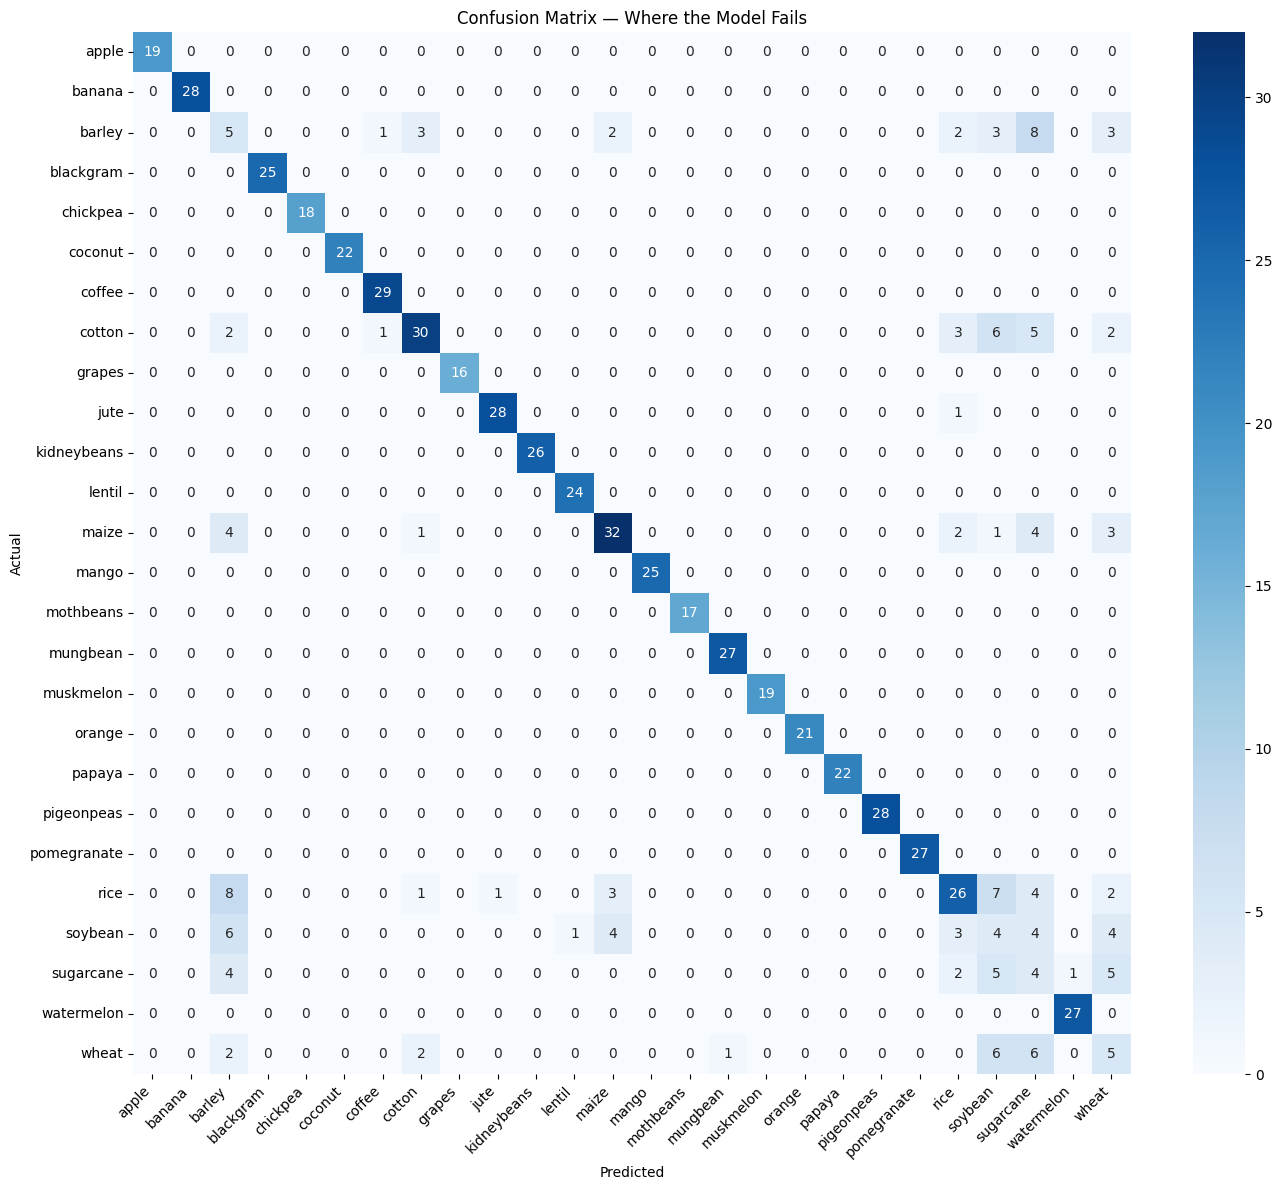

In [6]:
# See which crops are being confused with which
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — Where the Model Fails")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/figures/confusion_diagnostic.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
import pandas as pd
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

# Print only the confused crops to keep it readable
confused_crops = ["soybean", "sugarcane", "barley", "wheat", "rice", "cotton", "maize"]
print("=== Confusion Matrix (confused crops only) ===")
print(cm_df.loc[confused_crops, :].to_string())

=== Confusion Matrix (confused crops only) ===
           apple  banana  barley  blackgram  chickpea  coconut  coffee  cotton  grapes  jute  kidneybeans  lentil  maize  mango  mothbeans  mungbean  muskmelon  orange  papaya  pigeonpeas  pomegranate  rice  soybean  sugarcane  watermelon  wheat
soybean        0       0       6          0         0        0       0       0       0     0            0       1      4      0          0         0          0       0       0           0            0     3        4          4           0      4
sugarcane      0       0       4          0         0        0       0       0       0     0            0       0      0      0          0         0          0       0       0           0            0     2        5          4           1      5
barley         0       0       5          0         0        0       1       3       0     0            0       0      2      0          0         0          0       0       0           0            0     2        3

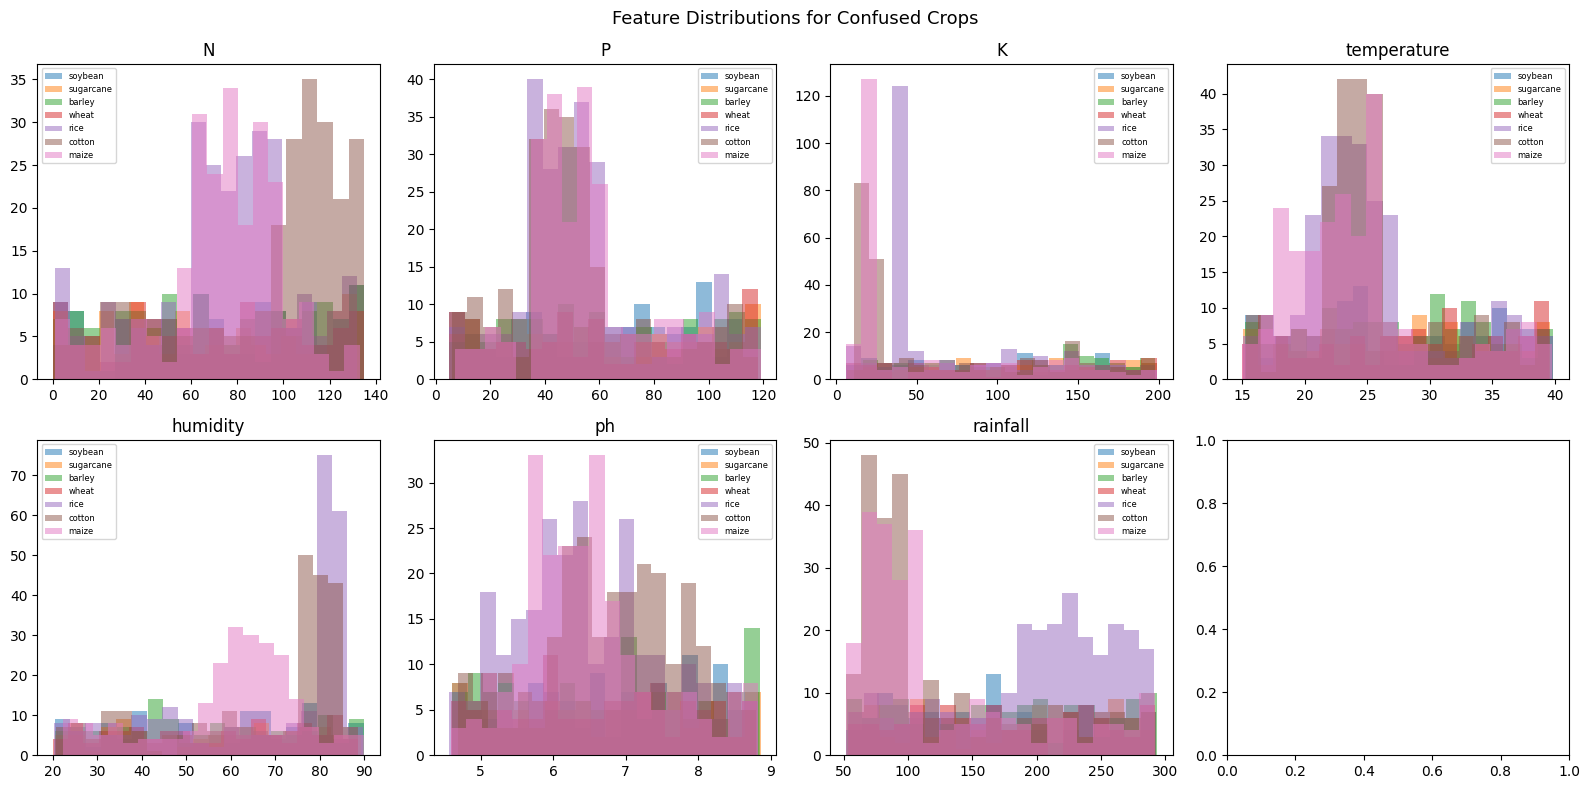

In [8]:
# Check feature distributions for confused crops
confused_crops = ["soybean", "sugarcane", "barley", "wheat", "rice", "cotton", "maize"]

df_confused = df_merged[df_merged["label"].isin(confused_crops)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

numeric_cols = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
for i, col in enumerate(numeric_cols):
    for crop in confused_crops:
        vals = df_confused[df_confused["label"] == crop][col]
        axes[i].hist(vals, alpha=0.5, label=crop, bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=6)

plt.suptitle("Feature Distributions for Confused Crops", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/confused_crops_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
import pandas as pd
import numpy as np

def add_engineered_features(df):
    df = df.copy()
    
    # --- Nutrient ratios (separates legumes from cereals) ---
    df["N_P_ratio"]    = df["N"] / (df["P"] + 1e-6)
    df["N_K_ratio"]    = df["N"] / (df["K"] + 1e-6)
    df["P_K_ratio"]    = df["P"] / (df["K"] + 1e-6)
    df["NPK_total"]    = df["N"] + df["P"] + df["K"]
    df["NPK_balance"]  = df["N"] / (df["NPK_total"] + 1e-6)  # N dominance ratio

    # --- Climate interaction features (separates rice/sugarcane/barley/wheat) ---
    df["temp_humidity"]       = df["temperature"] * df["humidity"]
    df["rainfall_humidity"]   = df["rainfall"]    * df["humidity"]
    df["temp_rainfall"]       = df["temperature"] * df["rainfall"]

    # --- Climate Stress Index (your existing CSI — keep it) ---
    df["temp_norm"]     = (df["temperature"] - df["temperature"].mean()) / df["temperature"].std()
    df["humidity_norm"] = (df["humidity"]    - df["humidity"].mean())    / df["humidity"].std()
    df["rainfall_norm"] = (df["rainfall"]    - df["rainfall"].mean())    / df["rainfall"].std()
    df["CSI"] = (
        0.4 * abs(df["temp_norm"]) +
        0.3 * abs(df["humidity_norm"]) +
        0.3 * abs(df["rainfall_norm"])
    )
    df = df.drop(columns=["temp_norm", "humidity_norm", "rainfall_norm"])

    # --- pH sensitivity bands (crops respond differently to pH ranges) ---
    df["ph_acidic"]   = (df["ph"] < 6.0).astype(int)
    df["ph_neutral"]  = ((df["ph"] >= 6.0) & (df["ph"] <= 7.5)).astype(int)
    df["ph_alkaline"] = (df["ph"] > 7.5).astype(int)

    # --- Rainfall category (helps separate rice/sugarcane from wheat/barley) ---
    df["rainfall_low"]    = (df["rainfall"] < 60).astype(int)
    df["rainfall_medium"] = ((df["rainfall"] >= 60) & (df["rainfall"] < 150)).astype(int)
    df["rainfall_high"]   = (df["rainfall"] >= 150).astype(int)

    return df

# Apply to merged dataset
df_eng = add_engineered_features(df_merged)

print(f"Original features : 7")
print(f"Engineered features: {df_eng.shape[1] - 2}")  # -2 for label and source
print(f"New columns added: {[c for c in df_eng.columns if c not in df_merged.columns]}")

Original features : 7
Engineered features: 22
New columns added: ['N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NPK_total', 'NPK_balance', 'temp_humidity', 'rainfall_humidity', 'temp_rainfall', 'CSI', 'ph_acidic', 'ph_neutral', 'ph_alkaline', 'rainfall_low', 'rainfall_medium', 'rainfall_high']


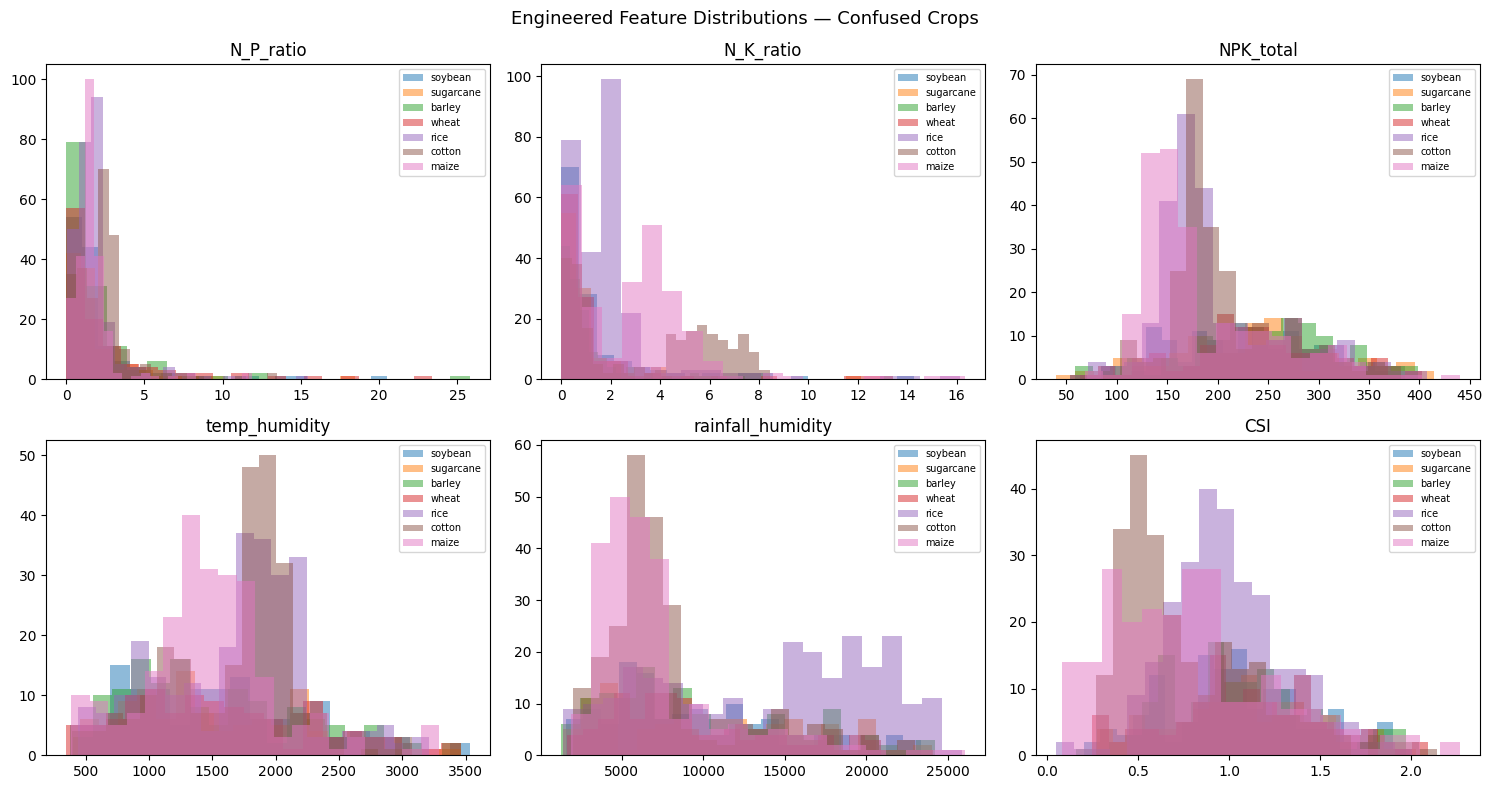

In [10]:
import matplotlib.pyplot as plt

# Check the most important new features for confused crops
confused_crops = ["soybean", "sugarcane", "barley", "wheat", "rice", "cotton", "maize"]
df_check = df_eng[df_eng["label"].isin(confused_crops)]

new_features = ["N_P_ratio", "N_K_ratio", "NPK_total", 
                "temp_humidity", "rainfall_humidity", "CSI"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(new_features):
    for crop in confused_crops:
        vals = df_check[df_check["label"] == crop][col]
        axes[i].hist(vals, alpha=0.5, label=crop, bins=20)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle("Engineered Feature Distributions — Confused Crops", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/engineered_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# FULL MODEL RETRAIN ON ENGINEERED FEATURES
# ============================================================

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# Drop label and source columns to get feature matrix
drop_cols = ["label"] + (["source"] if "source" in df_eng.columns else [])
X_eng = df_eng.drop(columns=drop_cols)
y_eng = le.transform(df_eng["label"])

print(f"Feature matrix: {X_eng.shape}")
print(f"Features: {list(X_eng.columns)}")

# Train/test split — stratified
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y_eng,
    test_size=0.2,
    random_state=42,
    stratify=y_eng
)

# SMOTE on training only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_e, y_train_sm_e = smote.fit_resample(X_train_e, y_train_e)

print(f"\nTrain (after SMOTE): {X_train_sm_e.shape[0]} | Test (real): {X_test_e.shape[0]}")

Feature matrix: (3463, 22)
Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NPK_total', 'NPK_balance', 'temp_humidity', 'rainfall_humidity', 'temp_rainfall', 'CSI', 'ph_acidic', 'ph_neutral', 'ph_alkaline', 'rainfall_low', 'rainfall_medium', 'rainfall_high']


D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(



Train (after SMOTE): 5434 | Test (real): 693


In [12]:
# ============================================================
# 5-FOLD CROSS VALIDATION — ALL MODELS
# ============================================================

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_full_e = np.vstack([X_train_sm_e, X_test_e.values])
y_full_e  = np.concatenate([y_train_sm_e, y_test_e])

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":       XGBClassifier(
                         objective="multi:softmax",
                         num_class=len(le.classes_),
                         eval_metric="mlogloss",
                         random_state=42,
                         verbosity=0
                     ),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_full_e, y_full_e, cv=skf, scoring="accuracy", n_jobs=-1)
    cv_results[name] = {
        "Mean Accuracy": round(scores.mean(), 4),
        "Std Dev":       round(scores.std(), 4),
        "95% CI Lower":  round(scores.mean() - 1.96 * scores.std(), 4),
        "95% CI Upper":  round(scores.mean() + 1.96 * scores.std(), 4),
    }
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

Decision Tree: 0.8520 ± 0.0061
Random Forest: 0.8813 ± 0.0080
XGBoost: 0.8738 ± 0.0057


In [13]:
# ============================================================
# ENSEMBLE — must be last (needs fitted base models)
# ============================================================

rf_e  = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
dt_e  = DecisionTreeClassifier(random_state=42)
xgb_e = XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

ensemble = VotingClassifier(
    estimators=[("rf", rf_e), ("dt", dt_e), ("xgb", xgb_e)],
    voting="soft"
)

ens_scores = cross_val_score(ensemble, X_full_e, y_full_e, cv=skf, scoring="accuracy", n_jobs=-1)
cv_results["Ensemble (RF+DT+XGB)"] = {
    "Mean Accuracy": round(ens_scores.mean(), 4),
    "Std Dev":       round(ens_scores.std(), 4),
    "95% CI Lower":  round(ens_scores.mean() - 1.96 * ens_scores.std(), 4),
    "95% CI Upper":  round(ens_scores.mean() + 1.96 * ens_scores.std(), 4),
}
print(f"Ensemble: {ens_scores.mean():.4f} ± {ens_scores.std():.4f}")

# Final results table
cv_df = pd.DataFrame(cv_results).T
print("\n=== FINAL CV RESULTS TABLE ===")
print(cv_df.to_string())
cv_df.to_csv("../results/tables/final_cv_results_engineered.csv")

Ensemble: 0.8655 ± 0.0066

=== FINAL CV RESULTS TABLE ===
                      Mean Accuracy  Std Dev  95% CI Lower  95% CI Upper
Decision Tree                0.8520   0.0061        0.8400        0.8640
Random Forest                0.8813   0.0080        0.8656        0.8970
XGBoost                      0.8738   0.0057        0.8627        0.8849
Ensemble (RF+DT+XGB)         0.8655   0.0066        0.8526        0.8784


In [14]:
# ============================================================
# FIT FINAL ENSEMBLE + CONFUSION MATRIX ON REAL TEST SET
# ============================================================

ensemble.fit(X_train_sm_e, y_train_sm_e)
y_pred_e = ensemble.predict(X_test_e)

print("=== Per-class Report (Ensemble, Engineered Features) ===")
print(classification_report(y_test_e, y_pred_e, target_names=le.classes_, digits=3))

# Confusion matrix — text version for comparison
cm_e    = confusion_matrix(y_test_e, y_pred_e)
cm_df_e = pd.DataFrame(cm_e, index=le.classes_, columns=le.classes_)

confused_crops = ["soybean", "sugarcane", "barley", "wheat", "rice", "cotton", "maize"]
print("\n=== Confusion Matrix (confused crops) ===")
print(cm_df_e.loc[confused_crops, :].to_string())

=== Per-class Report (Ensemble, Engineered Features) ===
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        19
      banana      1.000     1.000     1.000        28
      barley      0.346     0.333     0.340        27
   blackgram      0.962     1.000     0.980        25
    chickpea      1.000     1.000     1.000        18
     coconut      1.000     1.000     1.000        22
      coffee      1.000     0.966     0.982        29
      cotton      0.612     0.612     0.612        49
      grapes      1.000     1.000     1.000        16
        jute      0.931     0.931     0.931        29
 kidneybeans      1.000     1.000     1.000        26
      lentil      0.960     1.000     0.980        24
       maize      0.653     0.681     0.667        47
       mango      0.926     1.000     0.962        25
   mothbeans      1.000     1.000     1.000        17
    mungbean      0.964     1.000     0.982        27
   muskmelon      1.000 

In [15]:
# ============================================================
# HYPERPARAMETER TUNING — Random Forest (your best model)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
import numpy as np

param_grid = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", 0.5],
    "class_weight":      [None, "balanced"]  # balanced helps confused crops
}

rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf_tune,
    param_distributions=param_grid,
    n_iter=30,               # tries 30 random combinations
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_sm_e, y_train_sm_e)

print(f"\nBest parameters: {search.best_params_}")
print(f"Best CV accuracy: {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None}
Best CV accuracy: 0.8960


In [16]:
# ============================================================
# FINAL TUNED RF + ALL MODELS — Combined Cell
# ============================================================

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import pandas as pd

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Define tuned RF first ---
rf_best = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="log2",
    max_depth=30,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

# --- All models to evaluate ---
all_models = {
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(
                               objective="multi:softmax",
                               num_class=len(le.classes_),
                               eval_metric="mlogloss",
                               random_state=42, verbosity=0
                           ),
    "Tuned Random Forest": rf_best,
}

# --- CV for all models ---
final_results = {}
for name, model in all_models.items():
    scores = cross_val_score(model, X_full_e, y_full_e, cv=skf, scoring="accuracy", n_jobs=-1)
    final_results[name] = {
        "Mean Accuracy": round(scores.mean(), 4),
        "Std Dev":       round(scores.std(), 4),
        "95% CI Lower":  round(scores.mean() - 1.96 * scores.std(), 4),
        "95% CI Upper":  round(scores.mean() + 1.96 * scores.std(), 4),
    }
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

# --- Ensemble ---
ensemble = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ("dt",  DecisionTreeClassifier(random_state=42)),
        ("xgb", XGBClassifier(objective="multi:softmax", num_class=len(le.classes_),
                              eval_metric="mlogloss", random_state=42, verbosity=0))
    ],
    voting="soft"
)
ens_scores = cross_val_score(ensemble, X_full_e, y_full_e, cv=skf, scoring="accuracy", n_jobs=-1)
final_results["Ensemble (RF+DT+XGB)"] = {
    "Mean Accuracy": round(ens_scores.mean(), 4),
    "Std Dev":       round(ens_scores.std(), 4),
    "95% CI Lower":  round(ens_scores.mean() - 1.96 * ens_scores.std(), 4),
    "95% CI Upper":  round(ens_scores.mean() + 1.96 * ens_scores.std(), 4),
}
print(f"Ensemble: {ens_scores.mean():.4f} ± {ens_scores.std():.4f}")

# --- Results table ---
results_df = pd.DataFrame(final_results).T
print("\n=== PUBLISHABLE RESULTS TABLE ===")
print(results_df.to_string())
results_df.to_csv("../results/tables/final_publishable_results.csv")

# --- Fit tuned RF on training data + evaluate on real test set ---
rf_best.fit(X_train_sm_e, y_train_sm_e)
y_pred_best = rf_best.predict(X_test_e)

print("\nPer-class Report (Tuned RF, real test set):")
print(classification_report(y_test_e, y_pred_best, target_names=le.classes_, digits=3))

# Confused crops
cm_df = pd.DataFrame(
    confusion_matrix(y_test_e, y_pred_best),
    index=le.classes_, columns=le.classes_
)
confused_crops = ["soybean", "sugarcane", "barley", "wheat", "rice", "cotton", "maize"]
print("=== Confused crops (Tuned RF) ===")
print(cm_df.loc[confused_crops, :].to_string())

Decision Tree: 0.8520 ± 0.0061
Random Forest: 0.8813 ± 0.0080
XGBoost: 0.8738 ± 0.0057
Tuned Random Forest: 0.8825 ± 0.0051
Ensemble: 0.8655 ± 0.0066

=== PUBLISHABLE RESULTS TABLE ===
                      Mean Accuracy  Std Dev  95% CI Lower  95% CI Upper
Decision Tree                0.8520   0.0061        0.8400        0.8640
Random Forest                0.8813   0.0080        0.8656        0.8970
XGBoost                      0.8738   0.0057        0.8627        0.8849
Tuned Random Forest          0.8825   0.0051        0.8725        0.8925
Ensemble (RF+DT+XGB)         0.8655   0.0066        0.8526        0.8784

Per-class Report (Tuned RF, real test set):
              precision    recall  f1-score   support

       apple      1.000     1.000     1.000        19
      banana      0.966     1.000     0.982        28
      barley      0.111     0.111     0.111        27
   blackgram      1.000     1.000     1.000        25
    chickpea      1.000     1.000     1.000        18
     co

In [17]:
# ============================================================
# SHAP PLOTS — Fixed for shape (693, 22, 26)
# shap_values[sample, feature, class]
# ============================================================

import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X_test_df = pd.DataFrame(X_test_e, columns=X_eng.columns)

# Rearrange to (class, sample, feature) for compatibility
# shap_values shape: (n_samples, n_features, n_classes) → transpose
sv = np.transpose(shap_values, (2, 0, 1))
# sv[class_idx] = (n_samples, n_features)

print(f"Transposed SHAP shape: {sv.shape}")
print(f"Classes: {len(le.classes_)}, Features: {X_test_df.shape[1]}")

NameError: name 'shap_values' is not defined

In [ ]:
# --- Plot 1: Global Mean |SHAP| Bar Chart ---

mean_shap_per_feature = np.mean(
    [np.abs(sv[i]).mean(axis=0) for i in range(len(le.classes_))],
    axis=0
)  # shape: (n_features,)

shap_df = pd.DataFrame({
    "Feature":     list(X_eng.columns),
    "Mean |SHAP|": mean_shap_per_feature
}).sort_values("Mean |SHAP|", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(shap_df["Feature"], shap_df["Mean |SHAP|"], color="steelblue")
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("Global SHAP Feature Importance (Tuned RF, All Crops)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/shap_global_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 5 most important features:")
print(shap_df.head().to_string(index=False))

In [ ]:
# --- Plot 2: Beeswarm ---
# Use mean signed SHAP across classes: shape (n_samples, n_features)

mean_shap_signed = np.mean(sv, axis=0)  # (n_samples, n_features)

shap.summary_plot(
    mean_shap_signed,
    X_test_df,
    feature_names=list(X_eng.columns),
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Crop Prediction")
plt.tight_layout()
plt.savefig("../results/figures/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: shap_beeswarm.png")

In [ ]:
# --- Plot 3: Per-class SHAP for 6 confused crops ---

confused_crops = ["barley", "wheat", "rice", "sugarcane", "soybean", "cotton"]
f1_scores      = {"barley": 0.111, "wheat": 0.170, "rice": 0.556,
                  "sugarcane": 0.169, "soybean": 0.185, "cotton": 0.645}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, crop in zip(axes, confused_crops):
    class_idx = list(le.classes_).index(crop)
    vals      = sv[class_idx]                     # (n_samples, n_features)
    mean_abs  = np.abs(vals).mean(axis=0)         # (n_features,)
    top_idx   = np.argsort(mean_abs)[::-1][:8]    # top 8 feature indices

    feature_names = list(X_eng.columns)
    ax.barh(
        [feature_names[i] for i in top_idx[::-1]],
        mean_abs[top_idx[::-1]],
        color="darkorange"
    )
    ax.set_title(f"{crop.capitalize()} (F1={f1_scores[crop]:.3f})")
    ax.set_xlabel("Mean |SHAP|")

plt.suptitle("Per-Crop SHAP — Confused Crops with F1 Scores", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/shap_confused_crops.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: shap_confused_crops.png")

In [ ]:
# --- Plot 4: Waterfall — correctly predicted rice ---

rice_idx     = list(le.classes_).index("rice")
rice_correct = np.where((y_test_e == rice_idx) & (y_pred_best == rice_idx))[0]

if len(rice_correct) > 0:
    sample_i    = rice_correct[0]
    explanation = explainer(X_test_df.iloc[[sample_i]])
    # explanation.values shape: (1, n_features, n_classes)

    shap.plots.waterfall(explanation[0, :, rice_idx], show=False)
    plt.title("SHAP Waterfall — Correctly Predicted: Rice")
    plt.tight_layout()
    plt.savefig("../results/figures/shap_waterfall_rice.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: shap_waterfall_rice.png")
else:
    print("No correctly predicted rice samples found")

In [ ]:
# --- Plot 5: Waterfall — misclassified soybean ---

soybean_idx   = list(le.classes_).index("soybean")
soybean_wrong = np.where((y_test_e == soybean_idx) & (y_pred_best != soybean_idx))[0]

if len(soybean_wrong) > 0:
    sample_i    = soybean_wrong[0]
    wrong_label = le.inverse_transform([y_pred_best[sample_i]])[0]
    explanation = explainer(X_test_df.iloc[[sample_i]])

    shap.plots.waterfall(explanation[0, :, soybean_idx], show=False)
    plt.title(f"SHAP Waterfall — Soybean Misclassified as: {wrong_label.capitalize()}")
    plt.tight_layout()
    plt.savefig("../results/figures/shap_waterfall_soybean_wrong.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved — actual: soybean, predicted: {wrong_label}")
else:
    print("No wrong soybean predictions found")

In [ ]:
# --- Results summary for paper ---
print("=== TABLE II: MODEL COMPARISON ===")
print(results_df.to_string())

print("\n=== WEIGHTED AVERAGES (Tuned RF, test set) ===")
from sklearn.metrics import classification_report
report = classification_report(y_test_e, y_pred_best, 
                               target_names=le.classes_, 
                               digits=3, output_dict=True)
print(f"Precision : {report['weighted avg']['precision']:.3f}")
print(f"Recall    : {report['weighted avg']['recall']:.3f}")
print(f"F1-Score  : {report['weighted avg']['f1-score']:.3f}")
print(f"Accuracy  : {report['accuracy']:.3f}")

In [18]:
# CELL 1 — Imports and reload data
import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# Load merged clean data
df_merged = pd.read_csv("../data/processed/crop_merged_clean.csv")
print(f"Loaded: {df_merged.shape[0]} rows, {df_merged['label'].nunique()} crops")

Loaded: 3463 rows, 26 crops


In [21]:
# CELL 2 — Feature engineering (fixed)
def add_engineered_features(df):
    df = df.copy()
    df["N_P_ratio"]          = df["N"] / (df["P"] + 1e-6)
    df["N_K_ratio"]          = df["N"] / (df["K"] + 1e-6)
    df["P_K_ratio"]          = df["P"] / (df["K"] + 1e-6)
    df["NPK_total"]          = df["N"] + df["P"] + df["K"]
    df["NPK_balance"]        = df["N"] / (df["NPK_total"] + 1e-6)
    df["temp_humidity"]      = df["temperature"] * df["humidity"]
    df["rainfall_humidity"]  = df["rainfall"]    * df["humidity"]
    df["temp_rainfall"]      = df["temperature"] * df["rainfall"]
    df["temp_norm"]          = (df["temperature"] - df["temperature"].mean()) / df["temperature"].std()
    df["humidity_norm"]      = (df["humidity"]    - df["humidity"].mean())    / df["humidity"].std()
    df["rainfall_norm"]      = (df["rainfall"]    - df["rainfall"].mean())    / df["rainfall"].std()
    df["CSI"]                = (0.4 * abs(df["temp_norm"]) +
                                0.3 * abs(df["humidity_norm"]) +
                                0.3 * abs(df["rainfall_norm"]))
    df = df.drop(columns=["temp_norm", "humidity_norm", "rainfall_norm"])
    df["ph_acidic"]          = (df["ph"] < 6.0).astype(int)
    df["ph_neutral"]         = ((df["ph"] >= 6.0) & (df["ph"] <= 7.5)).astype(int)
    df["ph_alkaline"]        = (df["ph"] > 7.5).astype(int)
    df["rainfall_low"]       = (df["rainfall"] < 60).astype(int)
    df["rainfall_medium"]    = ((df["rainfall"] >= 60) & (df["rainfall"] < 150)).astype(int)
    df["rainfall_high"]      = (df["rainfall"] >= 150).astype(int)
    return df

df_eng = add_engineered_features(df_merged)

# DROP source column before feature matrix is built
if "source" in df_eng.columns:
    df_eng = df_eng.drop(columns=["source"])

print(f"Features after engineering: {df_eng.shape[1] - 1}")  # -1 for label
print(f"Columns: {list(df_eng.columns)}")

Features after engineering: 22
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NPK_total', 'NPK_balance', 'temp_humidity', 'rainfall_humidity', 'temp_rainfall', 'CSI', 'ph_acidic', 'ph_neutral', 'ph_alkaline', 'rainfall_low', 'rainfall_medium', 'rainfall_high']


In [22]:
# CELL 3 — Encode, split, SMOTE
le = LabelEncoder()
X_eng = df_eng.drop(columns=["label"])
y_eng = le.fit_transform(df_eng["label"])

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_eng, y_eng, test_size=0.2, random_state=42, stratify=y_eng
)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm_e, y_train_sm_e = smote.fit_resample(X_train_e, y_train_e)

print(f"Train: {X_train_sm_e.shape[0]} | Test: {X_test_e.shape[0]}")
print(f"Classes: {list(le.classes_)}")

Train: 5434 | Test: 693
Classes: ['apple', 'banana', 'barley', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'soybean', 'sugarcane', 'watermelon', 'wheat']


D:\crop_recommendation_ieee\venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [23]:
# CELL 4 — Fit tuned RF and ensemble
rf_best = RandomForestClassifier(
    n_estimators=200, min_samples_split=2, min_samples_leaf=1,
    max_features="log2", max_depth=30, class_weight=None,
    random_state=42, n_jobs=-1
)
rf_best.fit(X_train_sm_e, y_train_sm_e)
y_pred_best = rf_best.predict(X_test_e)

ensemble = VotingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ("dt",  DecisionTreeClassifier(random_state=42)),
        ("xgb", XGBClassifier(objective="multi:softmax", num_class=len(le.classes_),
                              eval_metric="mlogloss", random_state=42, verbosity=0))
    ], voting="soft"
)
ensemble.fit(X_train_sm_e, y_train_sm_e)

print("Models fitted successfully")

Models fitted successfully


In [24]:
# CELL 5 — All metrics for results section
from sklearn.metrics import classification_report

models_fitted = {
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(objective="multi:softmax", num_class=len(le.classes_),
                               eval_metric="mlogloss", random_state=42, verbosity=0),
    "Tuned Random Forest": rf_best,
    "Ensemble":            ensemble,
}

print("=== PER-MODEL TEST SET METRICS ===")
for name, model in models_fitted.items():
    if name not in ["Tuned Random Forest", "Ensemble"]:
        model.fit(X_train_sm_e, y_train_sm_e)
    y_pred_m = model.predict(X_test_e)
    r = classification_report(y_test_e, y_pred_m, output_dict=True)
    print(f"\n{name}:")
    print(f"  Accuracy : {r['accuracy']:.3f}")
    print(f"  Precision: {r['weighted avg']['precision']:.3f}")
    print(f"  Recall   : {r['weighted avg']['recall']:.3f}")
    print(f"  F1-Score : {r['weighted avg']['f1-score']:.3f}")

=== PER-MODEL TEST SET METRICS ===

Decision Tree:
  Accuracy : 0.795
  Precision: 0.793
  Recall   : 0.795
  F1-Score : 0.793

Random Forest:
  Accuracy : 0.798
  Precision: 0.812
  Recall   : 0.798
  F1-Score : 0.803

XGBoost:
  Accuracy : 0.797
  Precision: 0.801
  Recall   : 0.797
  F1-Score : 0.798

Tuned Random Forest:
  Accuracy : 0.795
  Precision: 0.812
  Recall   : 0.795
  F1-Score : 0.801

Ensemble:
  Accuracy : 0.805
  Precision: 0.802
  Recall   : 0.805
  F1-Score : 0.802


C:\Users\ashut\AppData\Local\Temp\ipykernel_17208\2136704854.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cv_plot_df["Model"], rotation=15, ha="right")


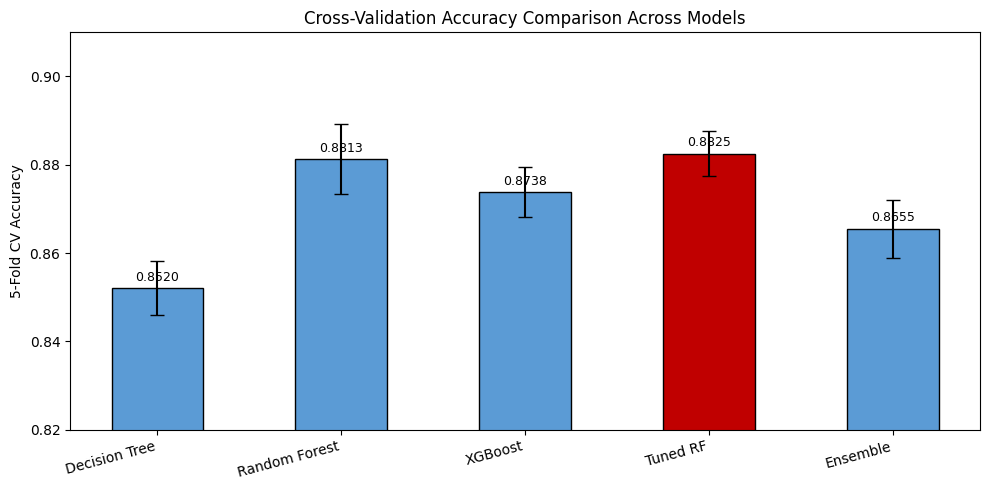

Saved: cv_accuracy_comparison.png


In [25]:
import matplotlib.pyplot as plt
import pandas as pd

cv_data = {
    "Model": ["Decision Tree", "Random Forest", "XGBoost", 
              "Tuned RF", "Ensemble"],
    "CV Accuracy": [0.8520, 0.8813, 0.8738, 0.8825, 0.8655],
    "Std Dev":     [0.0061, 0.0080, 0.0057, 0.0051, 0.0066]
}
cv_plot_df = pd.DataFrame(cv_data)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    cv_plot_df["Model"],
    cv_plot_df["CV Accuracy"],
    yerr=cv_plot_df["Std Dev"],
    capsize=5,
    color=["#5B9BD5", "#5B9BD5", "#5B9BD5", "#C00000", "#5B9BD5"],
    edgecolor="black",
    width=0.5
)

ax.set_ylim(0.82, 0.91)
ax.set_ylabel("5-Fold CV Accuracy")
ax.set_title("Cross-Validation Accuracy Comparison Across Models")
ax.set_xticklabels(cv_plot_df["Model"], rotation=15, ha="right")

# Add value labels on bars
for bar, val in zip(bars, cv_plot_df["CV Accuracy"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../results/figures/cv_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: cv_accuracy_comparison.png")


In [26]:
import shap
import numpy as np
import pandas as pd

# Recompute SHAP values
X_test_df = pd.DataFrame(X_test_e, columns=X_eng.drop(columns=["label"]).columns)

explainer   = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_df)

print(f"Type of shap_values: {type(shap_values)}")
print(f"Shape: {np.array(shap_values).shape}")
print(f"X_test_df shape: {X_test_df.shape}")
print(f"Number of classes: {len(le.classes_)}")
print(f"Number of features: {X_test_df.shape[1]}")

KeyError: "['label'] not found in axis"

In [27]:
import shap
import numpy as np
import pandas as pd

# X_eng already has no label column — use it directly for column names
X_test_df = pd.DataFrame(X_test_e, columns=X_eng.columns)

explainer   = shap.TreeExplainer(rf_best)
shap_values = explainer.shap_values(X_test_df)

print(f"Type of shap_values: {type(shap_values)}")
print(f"Shape: {np.array(shap_values).shape}")
print(f"X_test_df shape: {X_test_df.shape}")
print(f"Number of classes: {len(le.classes_)}")
print(f"Number of features: {X_test_df.shape[1]}")

Type of shap_values: <class 'numpy.ndarray'>
Shape: (693, 22, 26)
X_test_df shape: (693, 22)
Number of classes: 26
Number of features: 22


In [28]:
# SHAP CELL 1 — Transpose for easier indexing
# Rearrange to (26, 693, 22) = (classes, samples, features)
sv = np.transpose(shap_values, (2, 0, 1))
print(f"Transposed shape: {sv.shape}")
# sv[class_idx] gives (693, 22) — all samples for one class

Transposed shape: (26, 693, 22)


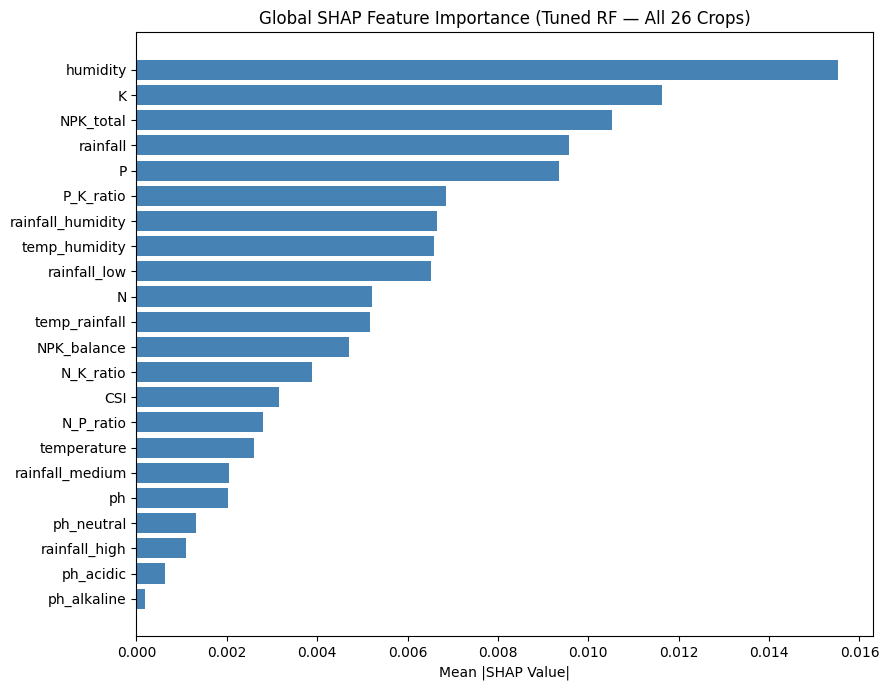

Top 5 features:
  Feature  Mean |SHAP|
 humidity     0.015533
        K     0.011625
NPK_total     0.010524
 rainfall     0.009562
        P     0.009340


In [29]:
# SHAP CELL 2 — Global Mean |SHAP| Bar Chart (Fig. 3)
import matplotlib.pyplot as plt

mean_shap_per_feature = np.mean(
    [np.abs(sv[i]).mean(axis=0) for i in range(len(le.classes_))],
    axis=0
)  # shape: (22,)

feature_names = list(X_eng.columns)
shap_df = pd.DataFrame({
    "Feature":     feature_names,
    "Mean |SHAP|": mean_shap_per_feature
}).sort_values("Mean |SHAP|", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df["Feature"], shap_df["Mean |SHAP|"], color="steelblue")
ax.set_xlabel("Mean |SHAP Value|")
ax.set_title("Global SHAP Feature Importance (Tuned RF — All 26 Crops)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../results/figures/shap_global_bar.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 5 features:")
print(shap_df.head().to_string(index=False))

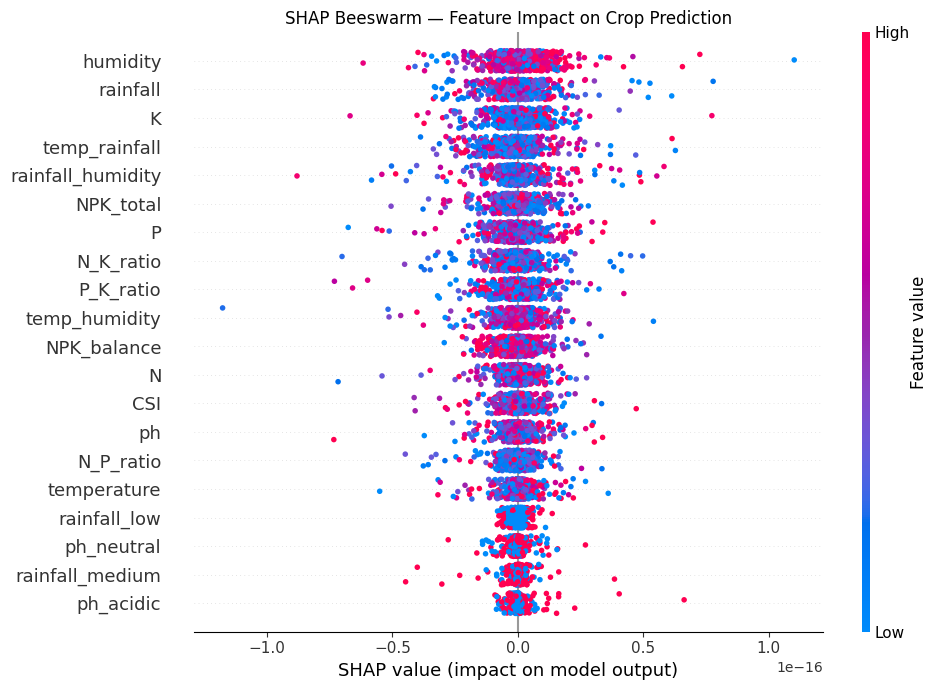

Saved: shap_beeswarm.png


In [30]:
# SHAP CELL 3 — Beeswarm Plot (Fig. 4)
import shap

mean_shap_signed = np.mean(sv, axis=0)  # (693, 22) — mean across classes

shap.summary_plot(
    mean_shap_signed,
    X_test_df,
    feature_names=feature_names,
    show=False,
    plot_size=(10, 7)
)
plt.title("SHAP Beeswarm — Feature Impact on Crop Prediction")
plt.tight_layout()
plt.savefig("../results/figures/shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: shap_beeswarm.png")

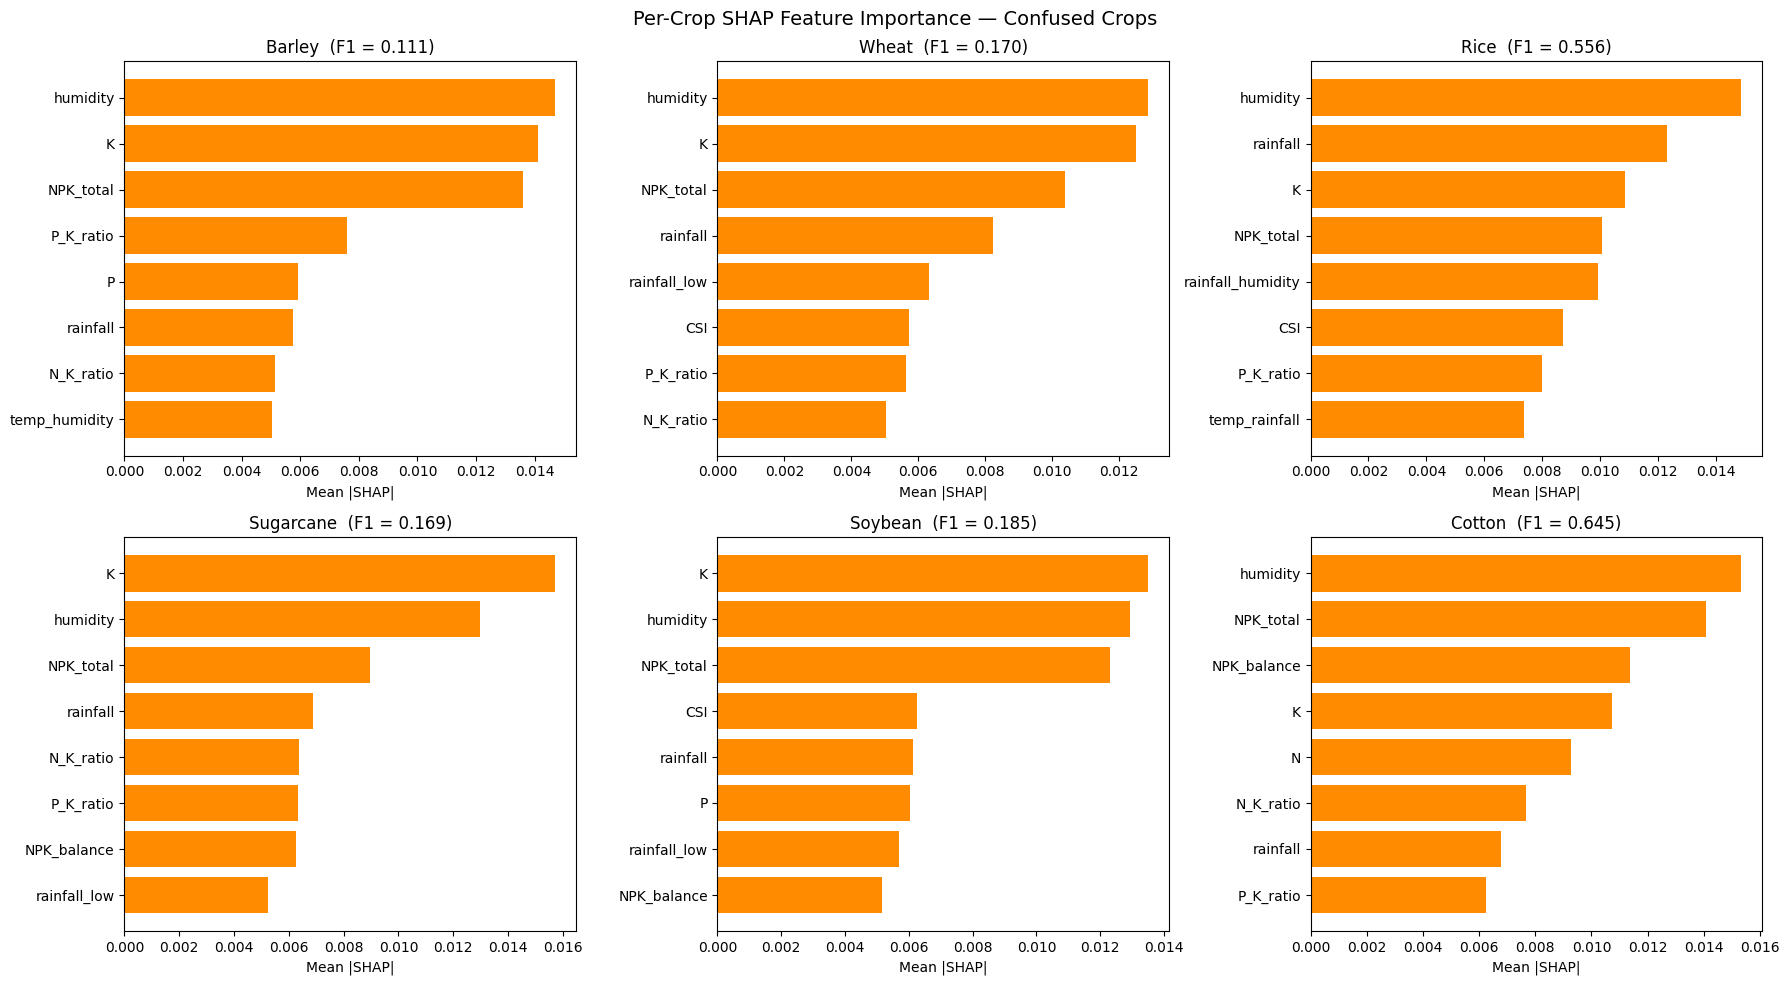

Saved: shap_confused_crops.png


In [31]:
# SHAP CELL 4 — Per-class SHAP for 6 confused crops (Fig. 5)
confused_crops = ["barley", "wheat", "rice", "sugarcane", "soybean", "cotton"]
f1_scores      = {
    "barley": 0.111, "wheat": 0.170, "rice": 0.556,
    "sugarcane": 0.169, "soybean": 0.185, "cotton": 0.645
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, crop in zip(axes, confused_crops):
    class_idx = list(le.classes_).index(crop)
    vals      = sv[class_idx]                  # (693, 22)
    mean_abs  = np.abs(vals).mean(axis=0)      # (22,)
    top_idx   = np.argsort(mean_abs)[::-1][:8] # top 8

    ax.barh(
        [feature_names[i] for i in top_idx[::-1]],
        mean_abs[top_idx[::-1]],
        color="darkorange"
    )
    ax.set_title(f"{crop.capitalize()}  (F1 = {f1_scores[crop]:.3f})")
    ax.set_xlabel("Mean |SHAP|")

plt.suptitle("Per-Crop SHAP Feature Importance — Confused Crops", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/shap_confused_crops.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: shap_confused_crops.png")

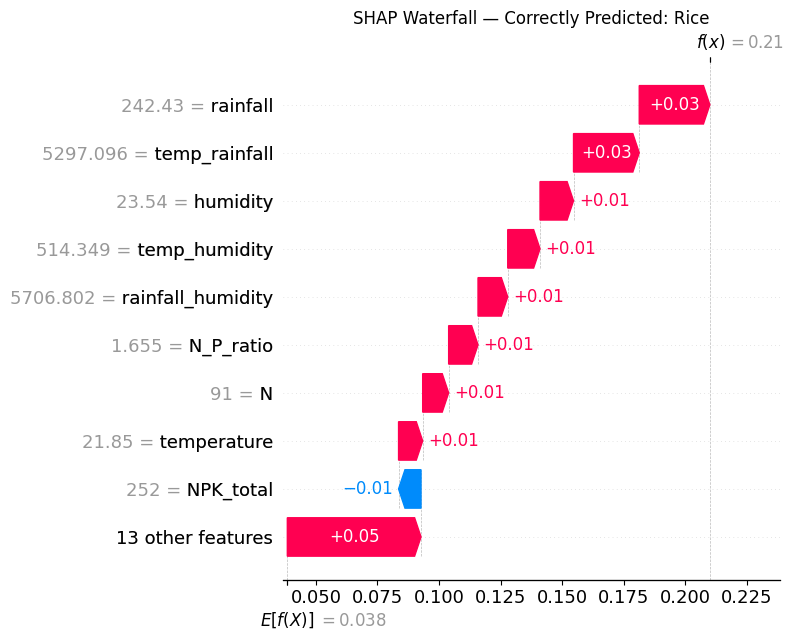

Saved: shap_waterfall_rice.png


In [32]:
# SHAP CELL 5 — Waterfall: correctly predicted rice (Fig. 6)
rice_idx     = list(le.classes_).index("rice")
rice_correct = np.where((y_test_e == rice_idx) & (y_pred_best == rice_idx))[0]

if len(rice_correct) > 0:
    sample_i    = rice_correct[0]
    explanation = explainer(X_test_df.iloc[[sample_i]])
    # explanation.values shape: (1, 22, 26)

    shap.plots.waterfall(explanation[0, :, rice_idx], show=False)
    plt.title("SHAP Waterfall — Correctly Predicted: Rice")
    plt.tight_layout()
    plt.savefig("../results/figures/shap_waterfall_rice.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: shap_waterfall_rice.png")
else:
    print("No correctly predicted rice samples found")

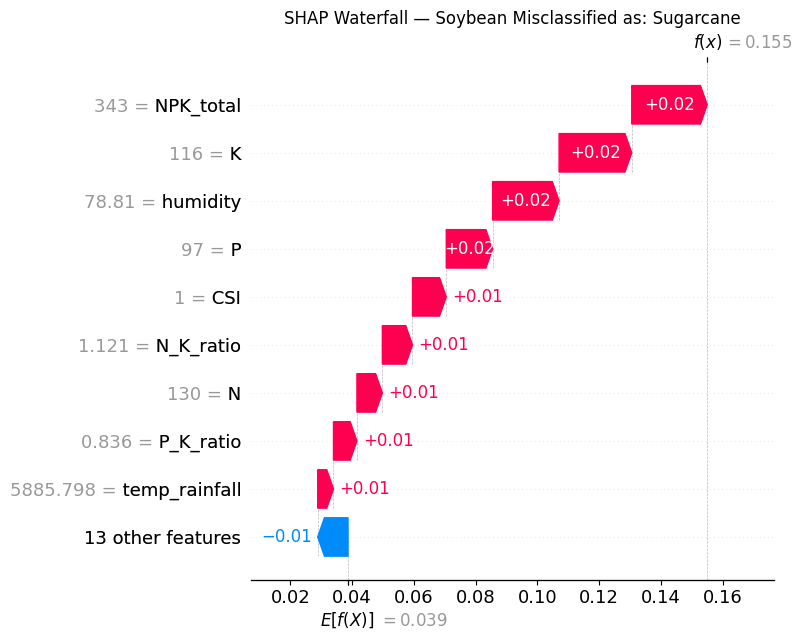

Saved — actual: soybean, predicted: sugarcane


In [33]:
# SHAP CELL 6 — Waterfall: misclassified soybean (Fig. 7)
soybean_idx   = list(le.classes_).index("soybean")
soybean_wrong = np.where(
    (y_test_e == soybean_idx) & (y_pred_best != soybean_idx)
)[0]

if len(soybean_wrong) > 0:
    sample_i    = soybean_wrong[0]
    wrong_label = le.inverse_transform([y_pred_best[sample_i]])[0]
    explanation = explainer(X_test_df.iloc[[sample_i]])

    shap.plots.waterfall(explanation[0, :, soybean_idx], show=False)
    plt.title(f"SHAP Waterfall — Soybean Misclassified as: {wrong_label.capitalize()}")
    plt.tight_layout()
    plt.savefig("../results/figures/shap_waterfall_soybean_wrong.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved — actual: soybean, predicted: {wrong_label}")
else:
    print("No misclassified soybean samples found")

In [35]:
import pickle
import os

# Create models folder at project root
os.makedirs(r"D:\crop_recommendation_ieee\models", exist_ok=True)

# Save everything the app needs in one bundle
model_bundle = {
    "model":         rf_best,
    "label_encoder": le,
    "feature_names": list(X_eng.columns),
    "feature_stats": {
        "temp_mean":     float(df_merged["temperature"].mean()),
        "temp_std":      float(df_merged["temperature"].std()),
        "humidity_mean": float(df_merged["humidity"].mean()),
        "humidity_std":  float(df_merged["humidity"].std()),
        "rainfall_mean": float(df_merged["rainfall"].mean()),
        "rainfall_std":  float(df_merged["rainfall"].std()),
    }
}

with open(r"D:\crop_recommendation_ieee\models\model_bundle.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("Saved: D:\\crop_recommendation_ieee\\models\\model_bundle.pkl")
print(f"Model type: {type(rf_best)}")
print(f"Classes: {list(le.classes_)}")
print(f"Features ({len(list(X_eng.columns))}): {list(X_eng.columns)}")

Saved: D:\crop_recommendation_ieee\models\model_bundle.pkl
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Classes: ['apple', 'banana', 'barley', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'soybean', 'sugarcane', 'watermelon', 'wheat']
Features (22): ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NPK_total', 'NPK_balance', 'temp_humidity', 'rainfall_humidity', 'temp_rainfall', 'CSI', 'ph_acidic', 'ph_neutral', 'ph_alkaline', 'rainfall_low', 'rainfall_medium', 'rainfall_high']


Loaded: 3463 rows, 26 crops
CSI computed. Range: 0.041 — 2.268


C:\Users\ashut\AppData\Local\Temp\ipykernel_12176\98818409.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,


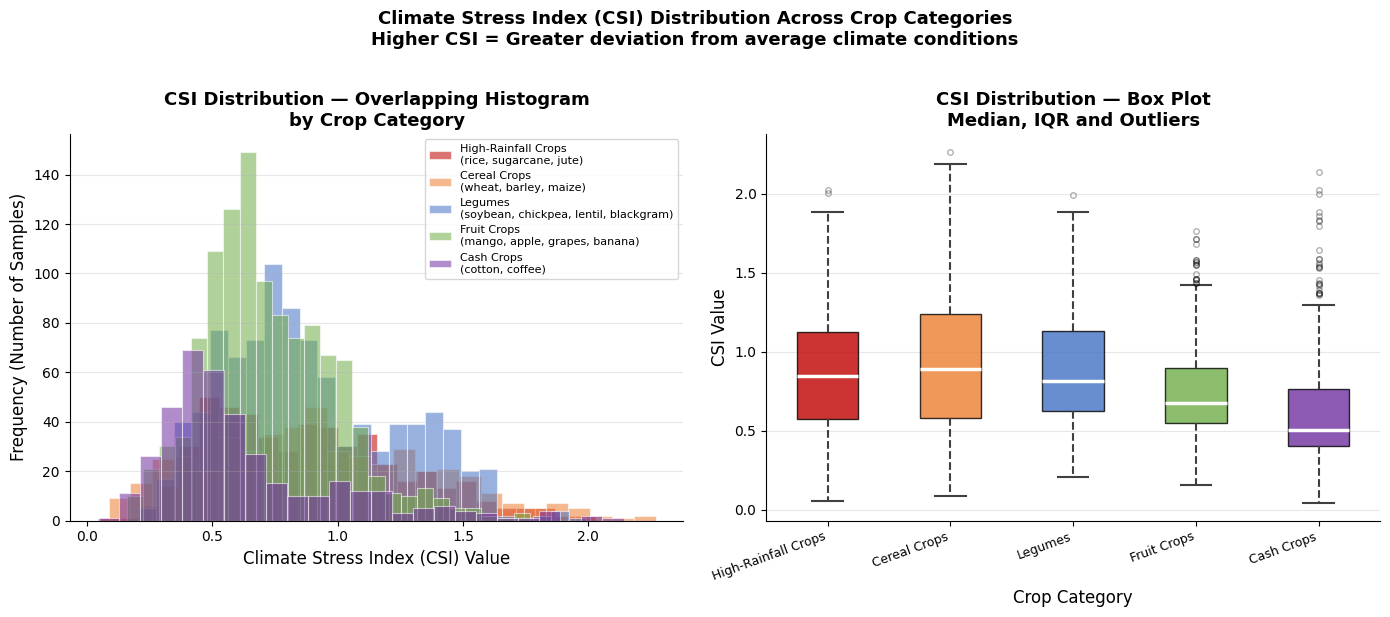

Saved: csi_distribution_by_category.png

=== CSI Summary Statistics by Category ===
High-Rainfall Crops                  mean=0.880  std=0.375  min=0.051  max=2.025
Cereal Crops                         mean=0.928  std=0.446  min=0.085  max=2.268
Legumes                              mean=0.885  std=0.348  min=0.203  max=1.992
Fruit Crops                          mean=0.729  std=0.265  min=0.158  max=1.765
Cash Crops                           mean=0.633  std=0.370  min=0.041  max=2.140


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df_merged = pd.read_csv("../data/processed/crop_merged_clean.csv")
print(f"Loaded: {df_merged.shape[0]} rows, {df_merged['label'].nunique()} crops")

# ── Compute CSI ───────────────────────────────────────────────────────────────
df_csi = df_merged.copy()  # ← this line was missing

df_csi["temp_norm"]     = (df_csi["temperature"] - df_csi["temperature"].mean()) / df_csi["temperature"].std()
df_csi["humidity_norm"] = (df_csi["humidity"]    - df_csi["humidity"].mean())    / df_csi["humidity"].std()
df_csi["rainfall_norm"] = (df_csi["rainfall"]    - df_csi["rainfall"].mean())    / df_csi["rainfall"].std()

df_csi["CSI"] = (
    0.4 * abs(df_csi["temp_norm"]) +
    0.3 * abs(df_csi["humidity_norm"]) +
    0.3 * abs(df_csi["rainfall_norm"])
)

print(f"CSI computed. Range: {df_csi['CSI'].min():.3f} — {df_csi['CSI'].max():.3f}")

# ── Define crop categories ────────────────────────────────────────────────────
category_map = {
    "High-Rainfall Crops\n(rice, sugarcane, jute)":   ["rice", "sugarcane", "jute"],
    "Cereal Crops\n(wheat, barley, maize)":            ["wheat", "barley", "maize"],
    "Legumes\n(soybean, chickpea, lentil, blackgram)": ["soybean", "chickpea", "lentil",
                                                         "blackgram", "mungbean",
                                                         "kidneybeans", "mothbeans",
                                                         "pigeonpeas"],
    "Fruit Crops\n(mango, apple, grapes, banana)":     ["mango", "apple", "grapes",
                                                         "banana", "muskmelon",
                                                         "watermelon", "orange",
                                                         "papaya", "pomegranate",
                                                         "coconut"],
    "Cash Crops\n(cotton, coffee)":                    ["cotton", "coffee"],
}

colors = ["#C00000", "#ED7D31", "#4472C4", "#70AD47", "#7030A0"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Histogram
for (cat_label, crops), color in zip(category_map.items(), colors):
    csi_vals = df_csi[df_csi["label"].isin(crops)]["CSI"]
    axes[0].hist(csi_vals, bins=25, alpha=0.55, label=cat_label,
                 color=color, edgecolor="white", linewidth=0.8)

axes[0].set_xlabel("Climate Stress Index (CSI) Value", fontsize=12)
axes[0].set_ylabel("Frequency (Number of Samples)", fontsize=12)
axes[0].set_title("CSI Distribution — Overlapping Histogram\nby Crop Category", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="y", alpha=0.3)

# Right: Box plot
box_data, box_labels, box_colors = [], [], []
for (cat_label, crops), color in zip(category_map.items(), colors):
    csi_vals = df_csi[df_csi["label"].isin(crops)]["CSI"].values
    box_data.append(csi_vals)
    box_labels.append(cat_label.split("\n")[0])
    box_colors.append(color)

bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True,
                     notch=False, widths=0.5,
                     medianprops=dict(color="white", linewidth=2.5))

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color); patch.set_alpha(0.8)
for whisker in bp["whiskers"]:
    whisker.set(color="#404040", linewidth=1.5, linestyle="--")
for cap in bp["caps"]:
    cap.set(color="#404040", linewidth=1.5)
for flier in bp["fliers"]:
    flier.set(marker="o", color="#404040", alpha=0.3, markersize=4)

axes[1].set_xlabel("Crop Category", fontsize=12)
axes[1].set_ylabel("CSI Value", fontsize=12)
axes[1].set_title("CSI Distribution — Box Plot\nMedian, IQR and Outliers", fontsize=13, fontweight="bold")
axes[1].set_xticklabels(box_labels, rotation=20, ha="right", fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Climate Stress Index (CSI) Distribution Across Crop Categories\n"
             "Higher CSI = Greater deviation from average climate conditions",
             fontsize=13, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("../results/figures/csi_distribution_by_category.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: csi_distribution_by_category.png")

# Summary stats
print("\n=== CSI Summary Statistics by Category ===")
for (cat_label, crops) in category_map.items():
    csi_vals = df_csi[df_csi["label"].isin(crops)]["CSI"]
    short = cat_label.split("\n")[0]
    print(f"{short:35s}  mean={csi_vals.mean():.3f}  std={csi_vals.std():.3f}  "
          f"min={csi_vals.min():.3f}  max={csi_vals.max():.3f}")

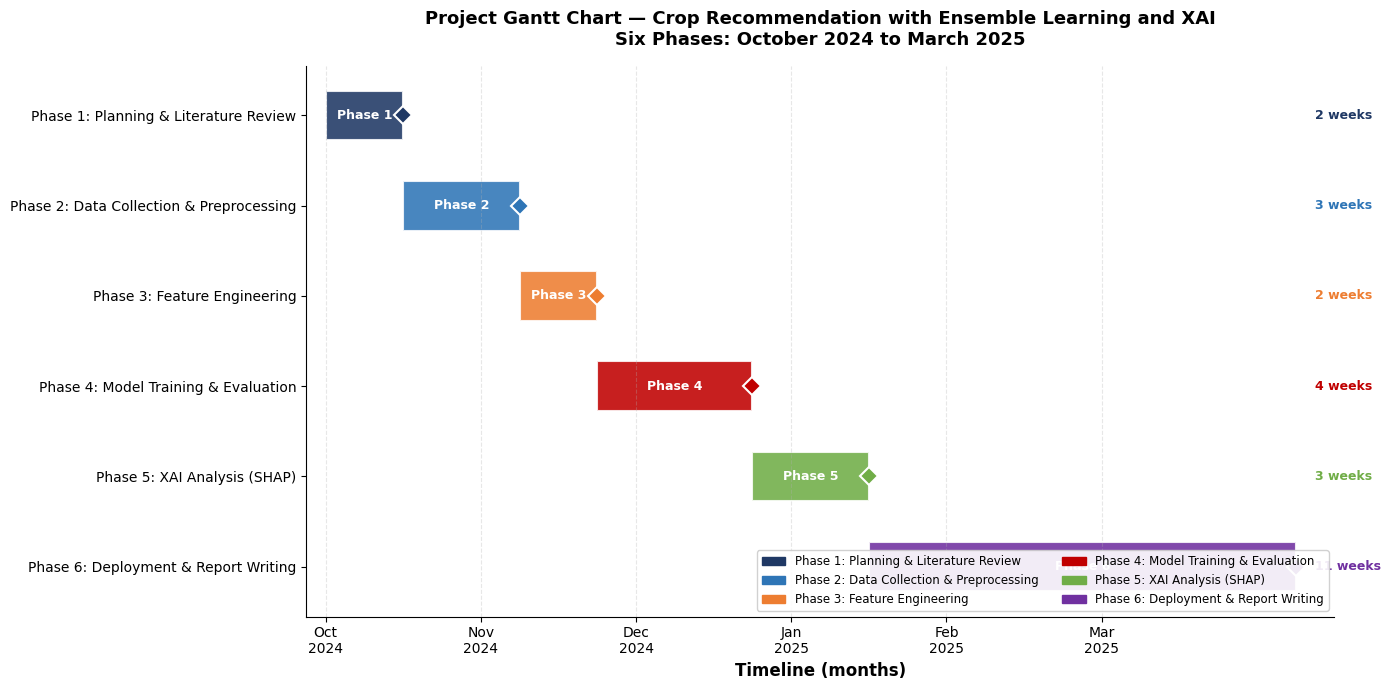

Saved: ../results/figures/gantt_chart.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(14, 7))

# ── Data ──────────────────────────────────────────────────────────────────────
phases = [
    "Phase 1: Planning & Literature Review",
    "Phase 2: Data Collection & Preprocessing",
    "Phase 3: Feature Engineering",
    "Phase 4: Model Training & Evaluation",
    "Phase 5: XAI Analysis (SHAP)",
    "Phase 6: Deployment & Report Writing",
]

# Start week and duration in weeks (0 = Oct 1)
starts   = [0,  2,  5,  7, 11, 14]
durations = [2,  3,  2,  4,  3,  11]

colors = ["#1F3864", "#2E75B6", "#ED7D31", "#C00000", "#70AD47", "#7030A0"]

# Month labels on x-axis (every 2 weeks = 0.5 month)
month_labels = ["Oct\n2024", "Nov\n2024", "Dec\n2024",
                "Jan\n2025", "Feb\n2025", "Mar\n2025"]
month_ticks  = [0, 4, 8, 12, 16, 20]

# ── Draw bars ─────────────────────────────────────────────────────────────────
for i, (phase, start, dur, color) in enumerate(zip(phases, starts, durations, colors)):
    # Main bar
    ax.barh(i, dur, left=start, height=0.55, color=color,
            alpha=0.88, edgecolor="white", linewidth=1.5)

    # Phase label inside bar if wide enough, otherwise outside
    label_x = start + dur / 2
    ax.text(label_x, i, f"Phase {i+1}",
            ha="center", va="center", fontsize=9,
            fontweight="bold", color="white")

# ── Milestones (diamonds at end of each phase) ─────────────────────────────────
milestone_positions = [s + d for s, d in zip(starts, durations)]
for i, (mx, color) in enumerate(zip(milestone_positions, colors)):
    ax.plot(mx, i, marker="D", markersize=9, color=color,
            markeredgecolor="white", markeredgewidth=1.5, zorder=5)

# ── Axis formatting ───────────────────────────────────────────────────────────
ax.set_yticks(range(len(phases)))
ax.set_yticklabels(phases, fontsize=10)
ax.set_xticks(month_ticks)
ax.set_xticklabels(month_labels, fontsize=10)
ax.set_xlim(-0.5, 26)
ax.set_xlabel("Timeline (months)", fontsize=12, fontweight="bold")
ax.set_title("Project Gantt Chart — Crop Recommendation with Ensemble Learning and XAI\n"
             "Six Phases: October 2024 to March 2025",
             fontsize=13, fontweight="bold", pad=15)

# ── Grid and styling ──────────────────────────────────────────────────────────
ax.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.invert_yaxis()

# ── Duration labels on right side ─────────────────────────────────────────────
durations_text = ["2 weeks", "3 weeks", "2 weeks", "4 weeks", "3 weeks", "11 weeks"]
for i, (dur_text, color) in enumerate(zip(durations_text, colors)):
    ax.text(25.5, i, dur_text, va="center", fontsize=9,
            color=color, fontweight="bold")

# ── Legend for phases ─────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=colors[0], label="Phase 1: Planning & Literature Review"),
    mpatches.Patch(color=colors[1], label="Phase 2: Data Collection & Preprocessing"),
    mpatches.Patch(color=colors[2], label="Phase 3: Feature Engineering"),
    mpatches.Patch(color=colors[3], label="Phase 4: Model Training & Evaluation"),
    mpatches.Patch(color=colors[4], label="Phase 5: XAI Analysis (SHAP)"),
    mpatches.Patch(color=colors[5], label="Phase 6: Deployment & Report Writing"),
]
ax.legend(handles=legend_patches, loc="lower right",
          fontsize=8.5, framealpha=0.9, ncol=2)

# ── Today marker (optional — remove if not needed) ───────────────────────────
# ax.axvline(x=25, color="red", linestyle=":", linewidth=1.5, label="Submission")

plt.tight_layout()
plt.savefig("../results/figures/gantt_chart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/gantt_chart.png")

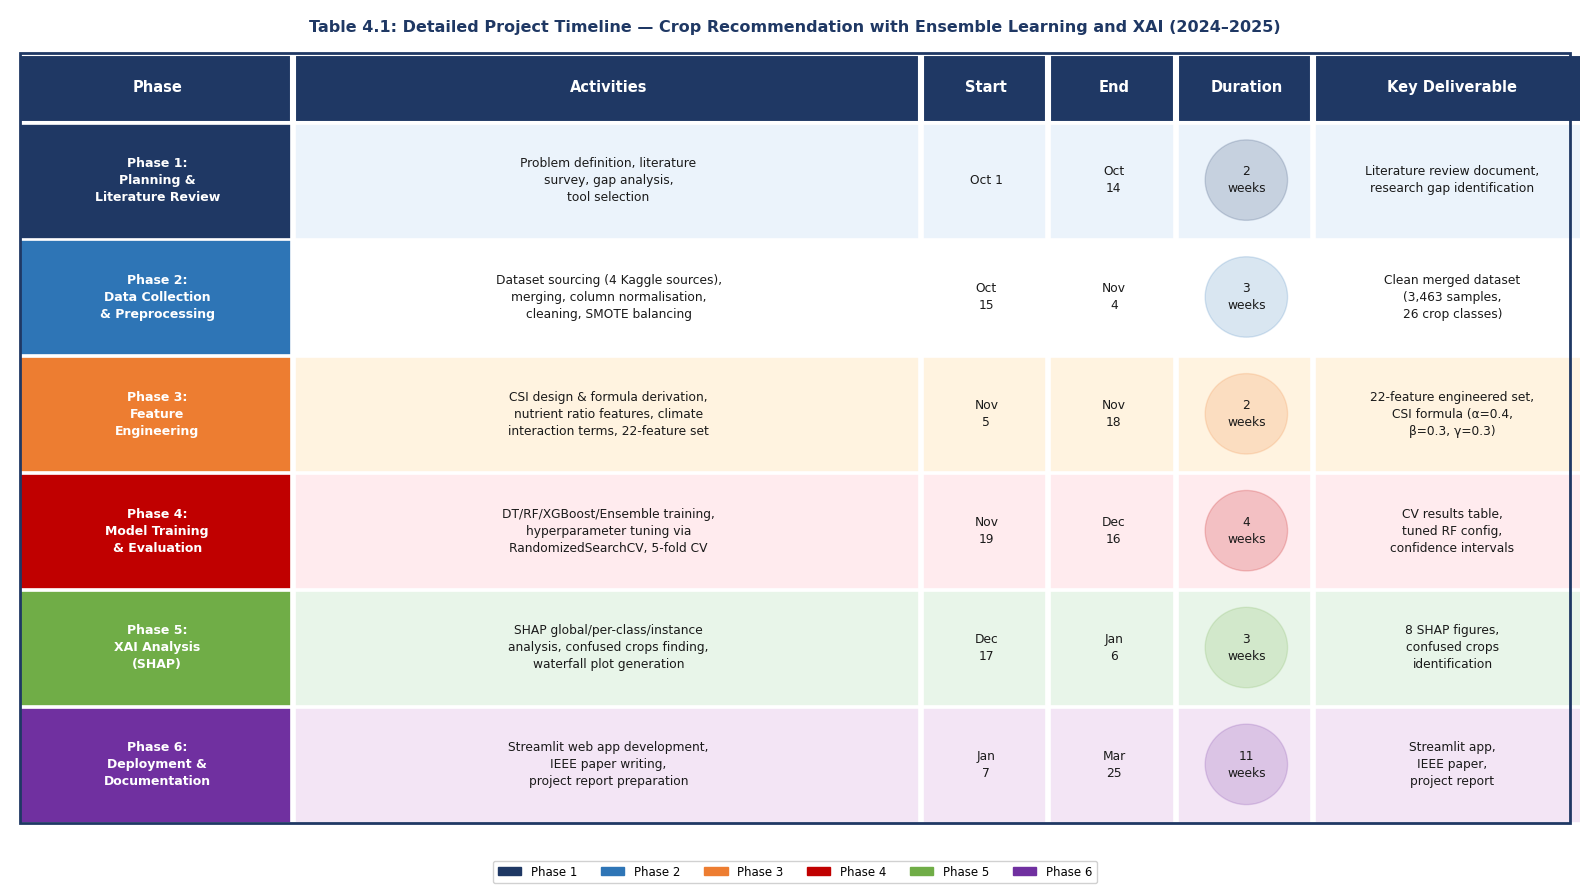

Saved: ../results/figures/table_4_1_timeline.png


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

# ── Table Data ────────────────────────────────────────────────────────────────
headers = ["Phase", "Activities", "Start", "End", "Duration", "Key Deliverable"]
col_x   = [0.0, 2.8, 9.2, 10.5, 11.8, 13.2]  # left edge of each column
col_w   = [2.8, 6.4, 1.3,  1.3,  1.4,  2.8]  # width of each column

rows = [
    ["Phase 1:\nPlanning &\nLiterature Review",
     "Problem definition, literature\nsurvey, gap analysis,\ntool selection",
     "Oct 1", "Oct\n14", "2\nweeks",
     "Literature review document,\nresearch gap identification"],
    ["Phase 2:\nData Collection\n& Preprocessing",
     "Dataset sourcing (4 Kaggle sources),\nmerging, column normalisation,\ncleaning, SMOTE balancing",
     "Oct\n15", "Nov\n4", "3\nweeks",
     "Clean merged dataset\n(3,463 samples,\n26 crop classes)"],
    ["Phase 3:\nFeature\nEngineering",
     "CSI design & formula derivation,\nnutrient ratio features, climate\ninteraction terms, 22-feature set",
     "Nov\n5", "Nov\n18", "2\nweeks",
     "22-feature engineered set,\nCSI formula (α=0.4,\nβ=0.3, γ=0.3)"],
    ["Phase 4:\nModel Training\n& Evaluation",
     "DT/RF/XGBoost/Ensemble training,\nhyperparameter tuning via\nRandomizedSearchCV, 5-fold CV",
     "Nov\n19", "Dec\n16", "4\nweeks",
     "CV results table,\ntuned RF config,\nconfidence intervals"],
    ["Phase 5:\nXAI Analysis\n(SHAP)",
     "SHAP global/per-class/instance\nanalysis, confused crops finding,\nwaterfall plot generation",
     "Dec\n17", "Jan\n6", "3\nweeks",
     "8 SHAP figures,\nconfused crops\nidentification"],
    ["Phase 6:\nDeployment &\nDocumentation",
     "Streamlit web app development,\nIEEE paper writing,\nproject report preparation",
     "Jan\n7", "Mar\n25", "11\nweeks",
     "Streamlit app,\nIEEE paper,\nproject report"],
]

phase_colors = ["#1F3864", "#2E75B6", "#ED7D31", "#C00000", "#70AD47", "#7030A0"]
row_bg       = ["#EBF3FB", "#FFFFFF", "#FFF3E0", "#FFEBEE", "#E8F5E9", "#F3E5F5"]
header_h     = 0.72
row_h        = 1.22
table_top    = 8.55
table_left   = 0.1
table_right  = 15.9
total_w      = table_right - table_left

# ── Draw Header ───────────────────────────────────────────────────────────────
for ci, (hdr, cx, cw) in enumerate(zip(headers, col_x, col_w)):
    ax.add_patch(FancyBboxPatch(
        (table_left + cx, table_top - header_h),
        cw - 0.04, header_h - 0.02,
        boxstyle="square,pad=0",
        facecolor="#1F3864", edgecolor="white", linewidth=1.5, zorder=3
    ))
    ax.text(table_left + cx + cw/2, table_top - header_h/2,
            hdr, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color="white", zorder=4)

# ── Draw Rows ─────────────────────────────────────────────────────────────────
for ri, (row, pcolor, rbg) in enumerate(zip(rows, phase_colors, row_bg)):
    y_top = table_top - header_h - ri * row_h

    for ci, (cell_text, cx, cw) in enumerate(zip(row, col_x, col_w)):

        # Background
        bg = pcolor if ci == 0 else rbg
        ax.add_patch(FancyBboxPatch(
            (table_left + cx, y_top - row_h),
            cw - 0.04, row_h - 0.02,
            boxstyle="square,pad=0",
            facecolor=bg, edgecolor="white", linewidth=1.2, zorder=2
        ))

        # Text colour
        txt_color = "white" if ci == 0 else "#1A1A1A"
        fw        = "bold"  if ci == 0 else "normal"
        fs        = 9.0     if ci == 0 else 8.8

        ax.text(table_left + cx + cw/2, y_top - row_h/2,
                cell_text, ha="center", va="center",
                fontsize=fs, fontweight=fw, color=txt_color,
                zorder=4, linespacing=1.4,
                wrap=True)

    # Duration badge (column 4) — circle highlight
    badge_x = table_left + col_x[4] + col_w[4]/2
    badge_y = y_top - row_h/2
    ax.add_patch(plt.Circle((badge_x, badge_y), 0.42,
                             color=pcolor, alpha=0.18, zorder=3))

# ── Outer border ──────────────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch(
    (table_left, table_top - header_h - len(rows)*row_h),
    total_w, header_h + len(rows)*row_h,
    boxstyle="square,pad=0",
    facecolor="none", edgecolor="#1F3864", linewidth=2.0, zorder=5
))

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(8.0, 8.82,
        "Table 4.1: Detailed Project Timeline — Crop Recommendation with Ensemble Learning and XAI (2024–2025)",
        ha="center", va="center", fontsize=11.5, fontweight="bold", color="#1F3864")

# ── Phase colour legend ───────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=c, label=f"Phase {i+1}")
    for i, c in enumerate(phase_colors)
]
ax.legend(handles=legend_patches, loc="lower center",
          ncol=6, fontsize=8.5, framealpha=0.9,
          bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("../results/figures/table_4_1_timeline.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/table_4_1_timeline.png")

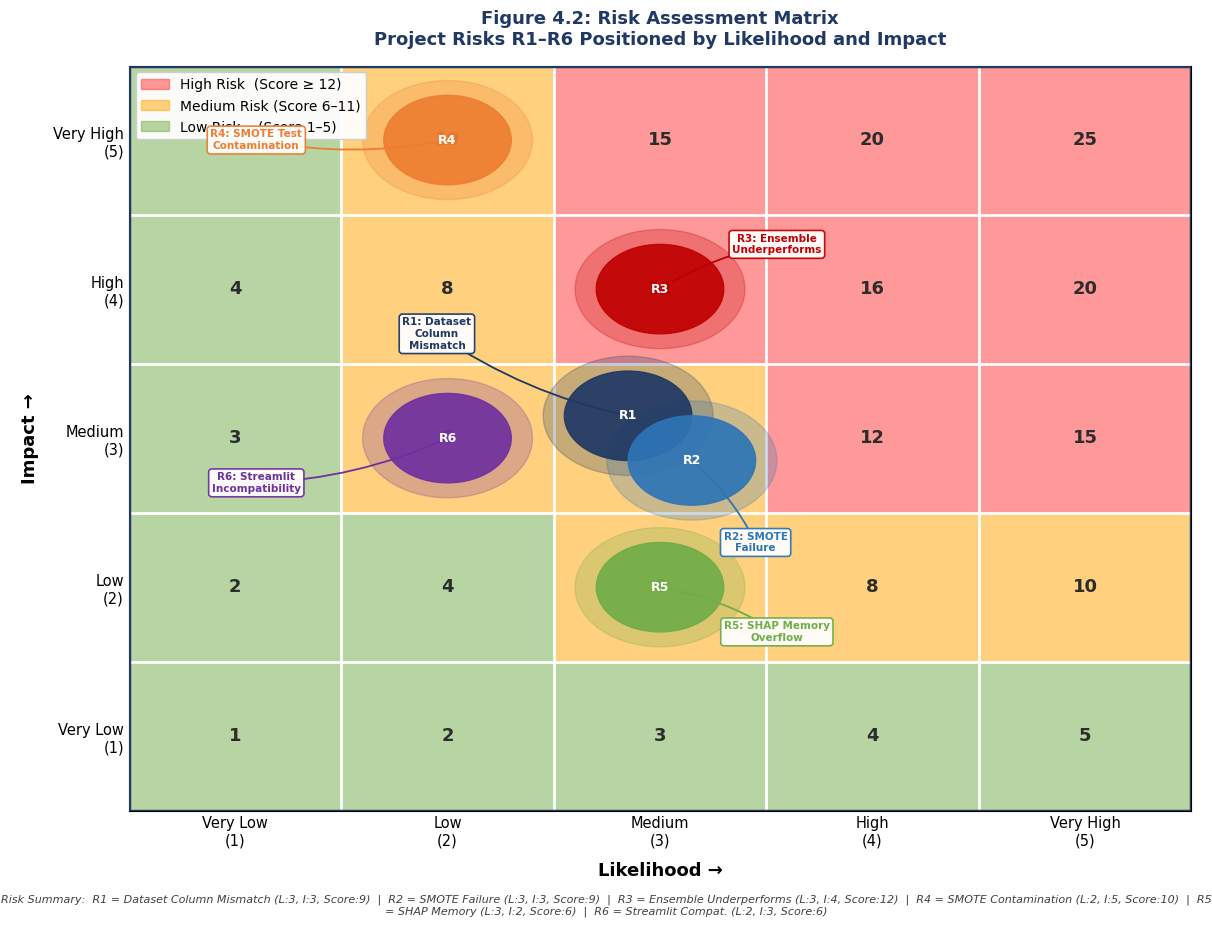

Saved: ../results/figures/fig_4_2_risk_matrix.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 9))

# ── Grid setup ────────────────────────────────────────────────────────────────
likelihood_labels = ["Very Low\n(1)", "Low\n(2)", "Medium\n(3)", "High\n(4)", "Very High\n(5)"]
impact_labels     = ["Very Low\n(1)", "Low\n(2)", "Medium\n(3)", "High\n(4)", "Very High\n(5)"]

# ── Draw coloured cells ───────────────────────────────────────────────────────
for i in range(5):       # likelihood (x)
    for j in range(5):   # impact (y)
        score = (i + 1) * (j + 1)
        if score >= 12:
            color = "#FF4444"   # High risk — red
            alpha = 0.55
        elif score >= 6:
            color = "#FFA500"   # Medium risk — orange
            alpha = 0.50
        else:
            color = "#70AD47"   # Low risk — green
            alpha = 0.50

        ax.add_patch(plt.Rectangle((i, j), 1, 1,
                                   color=color, alpha=alpha,
                                   zorder=1))
        # Score label in each cell
        ax.text(i + 0.5, j + 0.5, str(score),
                ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="#2C2C2C", zorder=2)

# ── Grid lines ────────────────────────────────────────────────────────────────
for i in range(6):
    ax.axvline(i, color="white", linewidth=2, zorder=3)
    ax.axhline(i, color="white", linewidth=2, zorder=3)

# ── Outer border ──────────────────────────────────────────────────────────────
ax.add_patch(plt.Rectangle((0, 0), 5, 5,
                            fill=False, edgecolor="#1F3864",
                            linewidth=2.5, zorder=4))

# ── Risk positions (likelihood-1, impact-1) ───────────────────────────────────
# R1: Dataset column mismatch     — Likelihood: Medium(3), Impact: Medium(3)
# R2: SMOTE failure               — Likelihood: Medium(3), Impact: Medium(3)
# R3: Ensemble underperforms      — Likelihood: Medium(3), Impact: High(4)
# R4: SMOTE test contamination    — Likelihood: Low(2),    Impact: Very High(5)
# R5: SHAP memory overflow        — Likelihood: Medium(3), Impact: Low(2)
# R6: Streamlit incompatibility   — Likelihood: Low(2),    Impact: Medium(3)

risks = {
    "R1": (2.35, 2.65, "#1F3864", "Dataset\nColumn\nMismatch"),
    "R2": (2.65, 2.35, "#2E75B6", "SMOTE\nFailure"),
    "R3": (2.5,  3.5,  "#C00000", "Ensemble\nUnderperforms"),
    "R4": (1.5,  4.5,  "#ED7D31", "SMOTE Test\nContamination"),
    "R5": (2.5,  1.5,  "#70AD47", "SHAP Memory\nOverflow"),
    "R6": (1.5,  2.5,  "#7030A0", "Streamlit\nIncompatibility"),
}

for label, (rx, ry, color, desc) in risks.items():
    # Outer glow circle
    ax.add_patch(plt.Circle((rx, ry), 0.40,
                             color=color, alpha=0.25, zorder=5))
    # Main filled circle
    ax.add_patch(plt.Circle((rx, ry), 0.30,
                             color=color, alpha=0.92,
                             zorder=6))
    # Risk label inside circle
    ax.text(rx, ry, label,
            ha="center", va="center",
            fontsize=9, fontweight="bold",
            color="white", zorder=7)

# ── Risk description callouts ─────────────────────────────────────────────────
callout_offsets = {
    "R1": (-0.9, +0.55),
    "R2": (+0.3, -0.55),
    "R3": (+0.55, +0.3),
    "R4": (-0.9, +0.0),
    "R5": (+0.55, -0.3),
    "R6": (-0.9, -0.3),
}

for label, (rx, ry, color, desc) in risks.items():
    dx, dy = callout_offsets[label]
    tx, ty = rx + dx, ry + dy

    # Annotation line
    ax.annotate("",
                xy=(rx, ry), xytext=(tx, ty),
                arrowprops=dict(arrowstyle="-",
                                color=color, lw=1.3,
                                connectionstyle="arc3,rad=0.1"),
                zorder=5)
    # Description box
    ax.text(tx, ty, f"{label}: {desc}",
            ha="center", va="center",
            fontsize=7.5, color=color,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white",
                      edgecolor=color,
                      linewidth=1.2,
                      alpha=0.95),
            zorder=8)

# ── Axis labels ───────────────────────────────────────────────────────────────
ax.set_xticks([i + 0.5 for i in range(5)])
ax.set_xticklabels(likelihood_labels, fontsize=10.5)
ax.set_yticks([i + 0.5 for i in range(5)])
ax.set_yticklabels(impact_labels, fontsize=10.5)
ax.set_xlabel("Likelihood →", fontsize=13, fontweight="bold", labelpad=10)
ax.set_ylabel("Impact →",     fontsize=13, fontweight="bold", labelpad=10)
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.tick_params(length=0)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title("Figure 4.2: Risk Assessment Matrix\n"
             "Project Risks R1–R6 Positioned by Likelihood and Impact",
             fontsize=13, fontweight="bold", pad=15, color="#1F3864")

# ── Legend ────────────────────────────────────────────────────────────────────
high_p = mpatches.Patch(color="#FF4444", alpha=0.55, label="High Risk  (Score ≥ 12)")
med_p  = mpatches.Patch(color="#FFA500", alpha=0.50, label="Medium Risk (Score 6–11)")
low_p  = mpatches.Patch(color="#70AD47", alpha=0.50, label="Low Risk    (Score 1–5)")
ax.legend(handles=[high_p, med_p, low_p],
          loc="upper left", fontsize=10,
          framealpha=0.95, edgecolor="#CCCCCC")

# ── Risk summary table below ──────────────────────────────────────────────────
summary_text = (
    "Risk Summary:  "
    "R1 = Dataset Column Mismatch (L:3, I:3, Score:9)  |  "
    "R2 = SMOTE Failure (L:3, I:3, Score:9)  |  "
    "R3 = Ensemble Underperforms (L:3, I:4, Score:12)  |  "
    "R4 = SMOTE Contamination (L:2, I:5, Score:10)  |  "
    "R5 = SHAP Memory (L:3, I:2, Score:6)  |  "
    "R6 = Streamlit Compat. (L:2, I:3, Score:6)"
)
fig.text(0.5, -0.02, summary_text,
         ha="center", fontsize=8, color="#404040",
         style="italic", wrap=True)

plt.tight_layout()
plt.savefig("../results/figures/fig_4_2_risk_matrix.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/fig_4_2_risk_matrix.png")

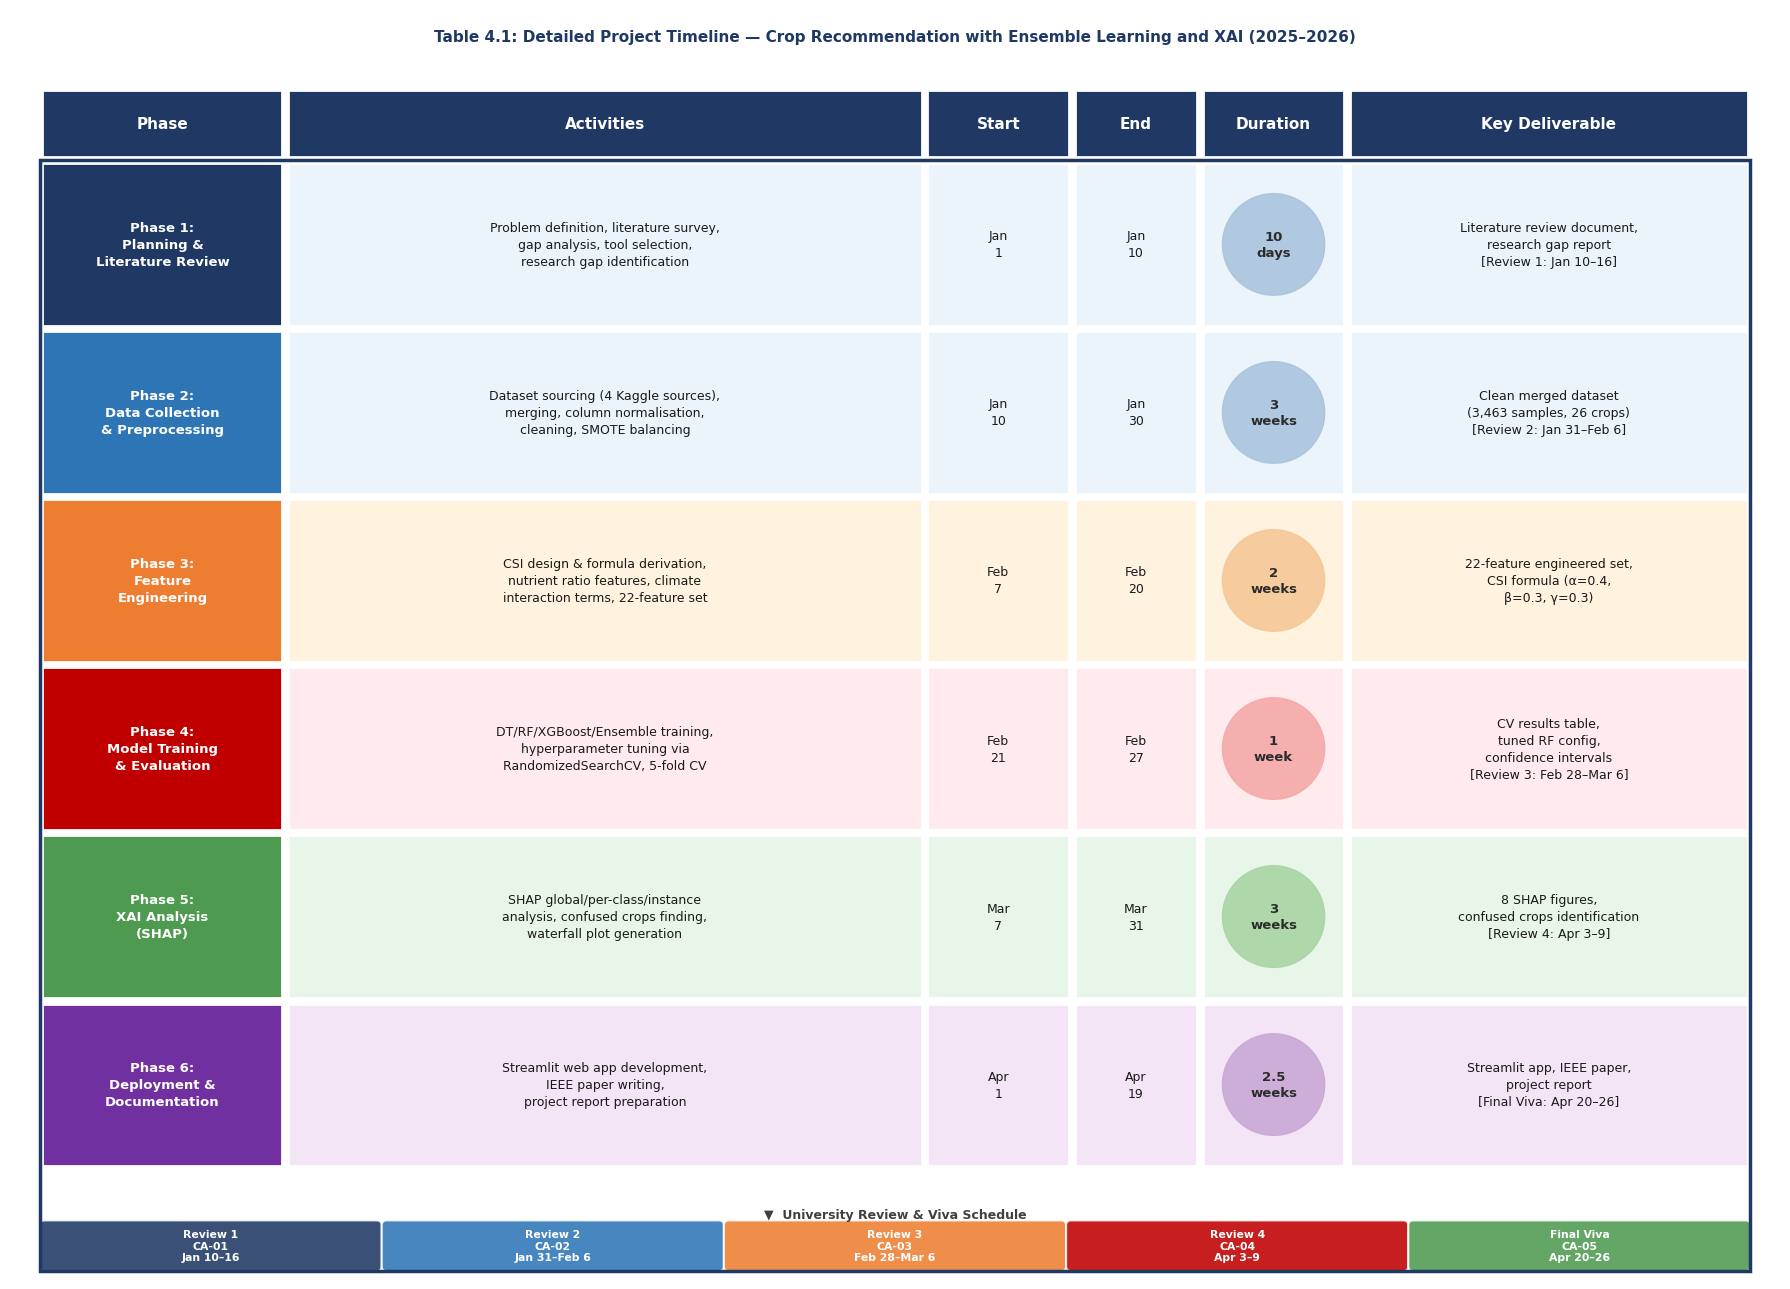

Saved: ../results/figures/table_4_1_timeline_updated.png


In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(18, 13))
ax.set_xlim(0, 18)
ax.set_ylim(0, 13)
ax.axis("off")
fig.patch.set_facecolor("white")

# ── Layout ────────────────────────────────────────────────────────────────────
table_left  = 0.3
table_right = 17.7
table_top   = 12.2
header_h    = 0.75
row_h       = 1.72
total_w     = table_right - table_left

col_x = [0.0,  2.5,  9.0, 10.5, 11.8, 13.3]
col_w = [2.5,  6.5,  1.5,  1.3,  1.5,  4.1]

headers = ["Phase", "Activities", "Start", "End", "Duration", "Key Deliverable"]

# ── Updated rows with your actual review dates ────────────────────────────────
rows = [
    ["Phase 1:\nPlanning &\nLiterature Review",
     "Problem definition, literature survey,\ngap analysis, tool selection,\nresearch gap identification",
     "Jan\n1", "Jan\n10", "10\ndays",
     "Literature review document,\nresearch gap report\n[Review 1: Jan 10–16]"],

    ["Phase 2:\nData Collection\n& Preprocessing",
     "Dataset sourcing (4 Kaggle sources),\nmerging, column normalisation,\ncleaning, SMOTE balancing",
     "Jan\n10", "Jan\n30", "3\nweeks",
     "Clean merged dataset\n(3,463 samples, 26 crops)\n[Review 2: Jan 31–Feb 6]"],

    ["Phase 3:\nFeature\nEngineering",
     "CSI design & formula derivation,\nnutrient ratio features, climate\ninteraction terms, 22-feature set",
     "Feb\n7", "Feb\n20", "2\nweeks",
     "22-feature engineered set,\nCSI formula (α=0.4,\nβ=0.3, γ=0.3)"],

    ["Phase 4:\nModel Training\n& Evaluation",
     "DT/RF/XGBoost/Ensemble training,\nhyperparameter tuning via\nRandomizedSearchCV, 5-fold CV",
     "Feb\n21", "Feb\n27", "1\nweek",
     "CV results table,\ntuned RF config,\nconfidence intervals\n[Review 3: Feb 28–Mar 6]"],

    ["Phase 5:\nXAI Analysis\n(SHAP)",
     "SHAP global/per-class/instance\nanalysis, confused crops finding,\nwaterfall plot generation",
     "Mar\n7", "Mar\n31", "3\nweeks",
     "8 SHAP figures,\nconfused crops identification\n[Review 4: Apr 3–9]"],

    ["Phase 6:\nDeployment &\nDocumentation",
     "Streamlit web app development,\nIEEE paper writing,\nproject report preparation",
     "Apr\n1", "Apr\n19", "2.5\nweeks",
     "Streamlit app, IEEE paper,\nproject report\n[Final Viva: Apr 20–26]"],
]

phase_colors = ["#1F3864", "#2E75B6", "#ED7D31", "#C00000", "#4E9A51", "#7030A0"]
row_bg       = ["#EBF3FB", "#EBF3FB", "#FFF3E0", "#FFEBEE", "#E8F5E9", "#F3E5F5"]
badge_colors = ["#AAC4DE", "#AAC4DE", "#F5C897", "#F4A9A8", "#A8D5A2", "#C9A8D5"]

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(9.0, 12.72,
        "Table 4.1: Detailed Project Timeline — Crop Recommendation with Ensemble Learning and XAI (2025–2026)",
        ha="center", va="center", fontsize=11, fontweight="bold", color="#1F3864")

# ── Header row ────────────────────────────────────────────────────────────────
for ci, (hdr, cx, cw) in enumerate(zip(headers, col_x, col_w)):
    ax.add_patch(FancyBboxPatch(
        (table_left + cx + 0.03, table_top - header_h + 0.03),
        cw - 0.06, header_h - 0.06,
        boxstyle="square,pad=0",
        facecolor="#1F3864", edgecolor="white",
        linewidth=2, zorder=3
    ))
    ax.text(table_left + cx + cw / 2,
            table_top - header_h / 2,
            hdr, ha="center", va="center",
            fontsize=11, fontweight="bold",
            color="white", zorder=4, linespacing=1.3)

# ── Data rows ─────────────────────────────────────────────────────────────────
for ri, (row, pcolor, rbg, bdg) in enumerate(
        zip(rows, phase_colors, row_bg, badge_colors)):

    y_top = table_top - header_h - ri * row_h

    for ci, (cell_text, cx, cw) in enumerate(zip(row, col_x, col_w)):

        bg = pcolor if ci == 0 else rbg

        ax.add_patch(FancyBboxPatch(
            (table_left + cx + 0.03, y_top - row_h + 0.03),
            cw - 0.06, row_h - 0.06,
            boxstyle="square,pad=0",
            facecolor=bg, edgecolor="white",
            linewidth=2, zorder=2
        ))

        # Duration — circular badge
        if ci == 4:
            bx = table_left + cx + cw / 2
            by = y_top - row_h / 2
            ax.add_patch(plt.Circle((bx, by), 0.52,
                                    color=bdg, zorder=3, alpha=0.9))
            ax.text(bx, by, cell_text,
                    ha="center", va="center",
                    fontsize=9.5, fontweight="bold",
                    color="#2C2C2C", zorder=4, linespacing=1.3)
            continue

        # Phase column
        if ci == 0:
            ax.text(table_left + cx + cw / 2, y_top - row_h / 2,
                    cell_text, ha="center", va="center",
                    fontsize=9.5, fontweight="bold",
                    color="white", zorder=4, linespacing=1.4)
        else:
            ax.text(table_left + cx + cw / 2, y_top - row_h / 2,
                    cell_text, ha="center", va="center",
                    fontsize=9.0, color="#1A1A1A",
                    zorder=4, linespacing=1.4)

# ── Review milestone strip at bottom ──────────────────────────────────────────
milestones = [
    ("Review 1\nCA-01\nJan 10–16", "#1F3864"),
    ("Review 2\nCA-02\nJan 31–Feb 6", "#2E75B6"),
    ("Review 3\nCA-03\nFeb 28–Mar 6", "#ED7D31"),
    ("Review 4\nCA-04\nApr 3–9", "#C00000"),
    ("Final Viva\nCA-05\nApr 20–26", "#4E9A51"),
]

strip_y = table_top - header_h - len(rows) * row_h - 0.55
strip_w = total_w / len(milestones)

for mi, (label, color) in enumerate(milestones):
    mx = table_left + mi * strip_w
    ax.add_patch(FancyBboxPatch(
        (mx + 0.05, strip_y - 0.45), strip_w - 0.1, 0.42,
        boxstyle="round,pad=0.05",
        facecolor=color, edgecolor="white",
        linewidth=1.5, alpha=0.88, zorder=3
    ))
    ax.text(mx + strip_w / 2, strip_y - 0.24,
            label, ha="center", va="center",
            fontsize=7.8, fontweight="bold",
            color="white", zorder=4, linespacing=1.2)

ax.text(9.0, strip_y + 0.08,
        "▼  University Review & Viva Schedule",
        ha="center", va="center",
        fontsize=9, fontweight="bold", color="#404040")

# ── Outer border ──────────────────────────────────────────────────────────────
ax.add_patch(FancyBboxPatch(
    (table_left, strip_y - 0.5),
    total_w,
    table_top - header_h - (strip_y - 0.5),
    boxstyle="square,pad=0",
    facecolor="none", edgecolor="#1F3864",
    linewidth=2.5, zorder=5
))

plt.tight_layout()
plt.savefig("../results/figures/table_4_1_timeline_updated.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ../results/figures/table_4_1_timeline_updated.png")